# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії — від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа — підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 — основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

**Студент:** Споденюк Володимир Вікторович

**Мій датасет:** Ames House Prices (визначається за SHA-256 від ПІБ у розділі 1.1)

**Як запускати:** ноутбук проходить зверху донизу (Run All). Файли моделей, логи TensorBoard і `results.csv` створюються поряд із ноутбуком — у папках `models/`, `runs/` і файлі `results.csv`.

## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.0. Налаштування середовища

Спочатку підключаю бібліотеки (докачую тільки те, чого ще нема в середовищі), фіксую seed, вибираю device і готую папки для артефактів. На відміну від демо, я не прив'язуюсь до Colab: за умовою ноутбук має запускатися в будь-якому середовищі, тому `assert IN_COLAB` прибрав, а Google Drive підключається тільки якщо вручну поставити `USE_DRIVE = True`.

In [1]:
import sys, os, random, shutil, hashlib, importlib, subprocess

def ensure(pip_name, import_name=None):
    """Ставить пакет тільки якщо його ще нема в середовищі."""
    try:
        importlib.import_module(import_name or pip_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

for pip_name, import_name in [("datasets", "datasets"), ("tensorboard", "tensorboard"),
                              ("gradio", "gradio"), ("seaborn", "seaborn"),
                              ("scikit-learn", "sklearn")]:
    ensure(pip_name, import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from scipy.stats import skew
from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.tensorboard import SummaryWriter

print("Бібліотеки підключено. torch:", torch.__version__)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Бібліотеки підключено. torch: 2.14.1+cu130


In [2]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed зафіксовано:", SEED)
print("Використовуємо:", device)

Seed зафіксовано: 42
Використовуємо: cpu


In [3]:
IN_COLAB = "google.colab" in sys.modules
USE_DRIVE = False   # True -> у Colab артефакти підуть на Google Drive (щоб пережили перезапуск сесії)

if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab2"
else:
    ARTIFACT_DIR = os.path.abspath(".")   # поруч із ноутбуком (у репозиторії це /lab2)

RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
MODELS_DIR = os.path.join(ARTIFACT_DIR, "models")
RESULTS_CSV = os.path.join(ARTIFACT_DIR, "results.csv")
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Running in Colab:", IN_COLAB)
print("Артефакти зберігаються в:", ARTIFACT_DIR)

Running in Colab: False
Артефакти зберігаються в: /tmp/build/final/lab2


### 0.1 Мої відповіді:

Для частини відповідей потрібні числа з демо (пропуски, лінійна регресія, нейромережа на California Housing). Запускати всі клітинки демо по одній тут незручно, тому нижче я відтворюю його пайплайн у стислому вигляді: ті самі кроки (завантаження, спліт 60/20/20, kNN-імпутація, `diag_coord`/`bedperroom`, стандартизація, `nn.Linear` і нейромережа `7 → 64 → 32 → 1`) і ті самі гіперпараметри. Усі змінні цього блоку мають префікс `cal_`, щоб не плутати їх із моїм датасетом Ames далі.

In [4]:
# ---------- California Housing: стисла версія пайплайну з демо (розділи 1.1 - 2.2) ----------
CAL_REPO = "fantkolja/california-housing-with-missing-data"
CAL_CSV = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

def load_california():
    # 1) основний шлях - той самий датасет з Hugging Face, що й у демо (пропуски в ньому вже є)
    try:
        df = load_dataset(CAL_REPO)["train"].to_pandas()
        return df, "Hugging Face (пропуски вже всередині)"
    except Exception as e:
        print(f"HF недоступний ({type(e).__name__}) -> беру оригінальні дані з CSV і додаю пропуски так само, як у h_1.1 демо")
    # 2) запасний шлях: збираємо ті самі 8 ознак + таргет з оригінального CSV
    raw = pd.read_csv(CAL_CSV)
    bedrooms = raw["total_bedrooms"].fillna(raw["total_rooms"] * (raw["total_bedrooms"] / raw["total_rooms"]).median())
    full = pd.DataFrame({
        "MedInc": raw["median_income"], "HouseAge": raw["housing_median_age"],
        "AveRooms": raw["total_rooms"] / raw["households"], "AveBedrms": bedrooms / raw["households"],
        "Population": raw["population"], "AveOccup": raw["population"] / raw["households"],
        "Latitude": raw["latitude"], "Longitude": raw["longitude"],
        "MedHouseVal": raw["median_house_value"] / 1e5,
    })
    feats = [c for c in full.columns if c != "MedHouseVal"]
    rng = np.random.default_rng(SEED)
    miss_rows = rng.choice(full.index, size=int(len(full) * 0.10), replace=False)
    for row in miss_rows:
        full.loc[row, rng.choice(feats)] = np.nan
    return full, "CSV + штучні пропуски (10% рядків)"

cal_df, cal_source = load_california()
print("Джерело:", cal_source, "| розмір:", cal_df.shape)
print("Пропусків по колонках:", cal_df.isna().sum().to_dict())

# спліт 60/20/20 одразу, до будь-якої обробки
cal_train_raw, _tmp = train_test_split(cal_df, test_size=0.4, random_state=SEED)
cal_val_raw, cal_test_raw = train_test_split(_tmp, test_size=0.5, random_state=SEED)

# kNN-імпутація рівно як у демо (1.5.3.2)
def fit_knn_imputers(reference_df, n_neighbors=5):
    ldf = reference_df.select_dtypes(include=[np.number])
    cols_nan = ldf.columns[ldf.isna().any()].tolist()
    cols_no_nan = ldf.columns.difference(cols_nan).values
    imp_train = ldf.dropna()
    models = {}
    for col in cols_nan:
        models[col] = KNeighborsRegressor(n_neighbors=n_neighbors).fit(imp_train[cols_no_nan], imp_train[col])
    return models, cols_no_nan

def apply_knn_imputers(df, models, cols_no_nan):
    ldf = df.select_dtypes(include=[np.number]).copy()
    for col, model in models.items():
        mask = ldf[col].isna()
        if mask.any():
            ldf.loc[mask, col] = model.predict(ldf.loc[mask, cols_no_nan])
    return ldf

cal_knn_models, cal_cols_no_nan = fit_knn_imputers(cal_train_raw)
print("\nКолонки-предиктори kNN-імпутера з демо:", list(cal_cols_no_nan))

cal_train, cal_val, cal_test = [apply_knn_imputers(d, cal_knn_models, cal_cols_no_nan)
                                for d in (cal_train_raw, cal_val_raw, cal_test_raw)]

# інженерія ознак з демо (1.8)
for d in (cal_train, cal_val, cal_test):
    d["diag_coord"] = d["Latitude"] + d["Longitude"]
    d["bedperroom"] = d["AveBedrms"] / d["AveRooms"]
    d.drop(columns=["Latitude", "Longitude", "AveBedrms"], inplace=True)

# стандартизація і тензори (2.1 - 2.2)
cal_features = [c for c in cal_train.columns if c != "MedHouseVal"]
cal_scaler = StandardScaler()
cal_X_train = cal_scaler.fit_transform(cal_train[cal_features])
cal_X_val = cal_scaler.transform(cal_val[cal_features])
cal_X_test = cal_scaler.transform(cal_test[cal_features])
cal_y_train, cal_y_val, cal_y_test = (d["MedHouseVal"].values for d in (cal_train, cal_val, cal_test))

def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32).to(device),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device))

cal_xtr, cal_ytr = to_tensor(cal_X_train, cal_y_train)
cal_xva, cal_yva = to_tensor(cal_X_val, cal_y_val)
cal_xte, cal_yte = to_tensor(cal_X_test, cal_y_test)

def calc_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": mse ** 0.5, "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

def report(y_true, y_pred, name):
    m = calc_metrics(y_true, y_pred)
    print(f"{name:26s}  MSE={m['MSE']:.4f}  RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  R2={m['R2']:.4f}")

print("\nОзнаки після feature engineering:", cal_features)
print("Розміри train/val/test:", cal_X_train.shape, cal_X_val.shape, cal_X_test.shape)

HF недоступний (FileNotFoundError) -> беру оригінальні дані з CSV і додаю пропуски так само, як у h_1.1 демо


Джерело: CSV + штучні пропуски (10% рядків) | розмір: (20640, 9)
Пропусків по колонках: {'MedInc': 241, 'HouseAge': 297, 'AveRooms': 248, 'AveBedrms': 267, 'Population': 249, 'AveOccup': 240, 'Latitude': 263, 'Longitude': 259, 'MedHouseVal': 0}

Колонки-предиктори kNN-імпутера з демо: ['MedHouseVal']

Ознаки після feature engineering: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'diag_coord', 'bedperroom']
Розміри train/val/test: (12384, 7) (4128, 7) (4128, 7)


#### Питання 1. Чому для заповнення пропусків було обрано метод kNN?

**Відповідь.** Медіана чи середнє вставляють у кожен пропуск одне й те саме число і взагалі не дивляться на інші ознаки рядка. Через це розподіл «стискається» до центру, а зв'язки між ознаками псуються (наприклад, широта і довгота перестають відповідати одна одній). kNN робить інакше: шукає в train 5 схожих будинків і бере їхнє значення, тому заповнене число залежить від самого рядка. До того ж метод простий, нічого не припускає про форму залежності (на відміну від лінійної моделі) і заповнює всі колонки однаково. Просто викинути рядки з пропусками теж не варіант: пропуски є в ~10% рядків, а у val/test і в реальному застосуванні такі рядки теж трапляться, і їх треба вміти заповнювати.

**Але є нюанс, і я його перевірив.** Подивіться на друк у клітинці вище: предикторами kNN-імпутера в демо є лише `['MedHouseVal']`. Так вийшло, бо функція бере колонки, де в train немає жодного пропуску, а пропуски розкидані по всіх 8 ознаках. Тобто демо-kNN шукає «будинки з подібною ціною», а ще використовує таргет рядків val/test, якого при реальному прогнозі в нас би не було. Нижче порівняння на повних рядках val, де я штучно ховаю по одній ознаці й дивлюсь, наскільки точно вона відновлюється (менше = краще):

| спосіб | середня нормована похибка |
|---|---|
| медіана | 0.870 |
| kNN з демо (лише таргет) | 0.854 |
| kNN по всіх інших ознаках | **0.477** |

Тож kNN з демо майже не кращий за медіану (а для `HouseAge`, `AveRooms`, `Population` навіть трохи гірший), зате kNN, який дивиться на інші ознаки, відновлює значення майже вдвічі точніше. Особливо видно на координатах: для `Latitude` похибка 1.157 (медіана) проти 0.269, для `Longitude` 1.095 проти 0.264, бо координата чудово підказується іншою координатою та районом. `Population` не вдається відновити жодним способом (≈1.08), а в `AveOccup` усі способи майже ідеальні (≈0.06), бо в неї дуже малий розкид. Висновок: сама ідея kNN правильна, але реалізація в демо використовує її не на повну. У своєму датасеті я kNN беру тільки для `LotFrontage`, предиктори — усі числові ознаки без таргету.

In [5]:
# Перевіряємо kNN-імпутацію чесно: беремо ПОВНІ рядки val, ховаємо в кожному одну випадкову ознаку
# (як у демо), і порівнюємо відновлене значення зі справжнім. Усі імпутери навчені тільки на train.
cal_feat_raw = [c for c in cal_df.columns if c != "MedHouseVal"]

val_complete = cal_val_raw.dropna().copy()
rng = np.random.default_rng(SEED)
hidden_col = rng.choice(cal_feat_raw, size=len(val_complete))
val_masked = val_complete.copy()
for c in cal_feat_raw:
    val_masked.loc[hidden_col == c, c] = np.nan

# (а) медіана train
medians = cal_train_raw[cal_feat_raw].median()
# (б) kNN з демо (предиктор там лише таргет - див. друк вище)
imp_demo = apply_knn_imputers(val_masked, cal_knn_models, cal_cols_no_nan)
# (в) kNN, який дивиться на ВСІ інші ознаки (стандартизовані), таргет не використовує
train_complete = cal_train_raw.dropna()
imp_all = {}
for c in cal_feat_raw:
    others = [x for x in cal_feat_raw if x != c]
    m = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)).fit(train_complete[others], train_complete[c])
    idx = val_masked[c].isna()
    imp_all[c] = pd.Series(m.predict(val_masked.loc[idx, others]), index=val_masked.index[idx])

rows = []
for c in cal_feat_raw:
    idx = val_masked[c].isna()
    truth = val_complete.loc[idx, c]
    sd = cal_train_raw[c].std()
    nrmse = lambda pred: float(np.sqrt(((truth - pred) ** 2).mean()) / sd)
    rows.append({"ознака": c, "прихованих": int(idx.sum()),
                 "медіана": nrmse(medians[c]),
                 "kNN з демо (лише таргет)": nrmse(imp_demo.loc[idx, c]),
                 "kNN по всіх ознаках": nrmse(imp_all[c])})
cmp_df = pd.DataFrame(rows).set_index("ознака")
cmp_df.loc["СЕРЕДНЄ"] = cmp_df.mean(numeric_only=True)
cmp_df["прихованих"] = cmp_df["прихованих"].fillna(0).astype(int)
print("Нормована похибка відновлення (RMSE / std ознаки на train), менше = краще:")
cmp_df.round(3)

Нормована похибка відновлення (RMSE / std ознаки на train), менше = краще:


,прихованих,медіана,kNN з демо (лише таргет),kNN по всіх ознаках
ознака,,,,
MedInc,445,0.881,0.689,0.551
HouseAge,497,0.994,1.072,0.835
AveRooms,449,1.165,1.208,0.449
AveBedrms,484,0.461,0.531,0.304
Population,451,1.146,1.190,1.082
AveOccup,448,0.060,0.071,0.063
Latitude,480,1.157,1.003,0.269
Longitude,467,1.095,1.065,0.264
СЕРЕДНЄ,465,0.870,0.854,0.477


#### Питання 2. Чому при тренуванні лінійної регресії train і val порівнюються лише за MSE, а після тренування — за багатьма метриками?

**Відповідь.** Під час тренування градієнтний спуск мінімізує саме **MSE**, тому саме її природно показувати на train і на val: це та функція, яку оптимізатор реально зменшує, і за її кривими видно, чи модель вчиться, чи вже перенавчається. Інші метрики під час тренування нічого нового не додають:

- **RMSE** = √MSE, та сама крива в іншому масштабі;
- **R²** = 1 − MSE / Var(y). Дисперсія y на фіксованому наборі даних стала, тож R² це та сама MSE, тільки «перевернута»;
- **MAE** рухається разом із MSE, тільки трохи інакше зважує великі помилки.

На графіках вище це видно: `val_MSE`, `val_MAE` і `val_R2` виходять на плато одночасно (близько 15-20-ї епохи), причому R² дзеркальний до MSE. Рахувати їх на кожній епосі нема сенсу.

Після тренування метрик потрібно кілька, бо вони відповідають на різні питання: RMSE і MAE показують типову помилку в одиницях таргета (сотні тисяч доларів), MAE менше «лякається» поодиноких великих промахів, а R² каже, яку частку розкиду ціни модель пояснила, і порівнюється між датасетами. Їх рахують один раз на test, цикл тренування вони не гальмують.

**Експеримент із вибором функції втрат.** Щоб перевірити, чи метрика, яку ми дивимось після тренування, залежить від того, чим тренували, я натренував ту саму лінійну регресію (SGD, `lr=0.1`, 300 епох) з трьома loss-функціями.

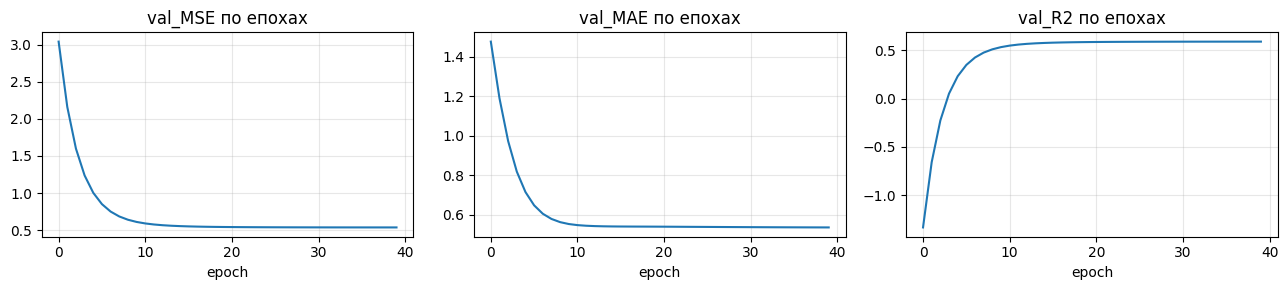

Метрики на test для лінійної регресії, натренованої з різними loss:


,MSE,RMSE,MAE,R2
"loss, яким тренували",,,,
MSE (MSELoss),0.5546,0.7447,0.5381,0.5955
MAE (L1Loss),0.5818,0.7627,0.5258,0.5757
Huber (delta=1),0.5612,0.7491,0.5302,0.5907


In [6]:
def train_cal_linear(loss_fn, epochs=40, lr=0.1):
    """Лінійна регресія на California як у демо (SGD, повний батч). Заодно пишемо в історію MSE/MAE/R2 на val."""
    set_seed()
    model = torch.nn.Linear(cal_xtr.shape[1], 1).to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_loss": [], "val_MSE": [], "val_MAE": [], "val_R2": []}
    yv = cal_yva.cpu().numpy().ravel()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(cal_xtr), cal_ytr)
        loss.backward()
        opt.step()
        model.eval()
        with torch.no_grad():
            pv = model(cal_xva)
            hist["train_loss"].append(loss.item())
            hist["val_loss"].append(loss_fn(pv, cal_yva).item())
            m = calc_metrics(yv, pv.cpu().numpy().ravel())
            for k in ("MSE", "MAE", "R2"):
                hist["val_" + k].append(m[k])
    return model, hist

# крок 1: MSE-модель з демо (40 епох, lr=0.1) - дивимось, як усі метрики на val рухаються разом
cal_linear, cal_hist = train_cal_linear(torch.nn.MSELoss(), epochs=40, lr=0.1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, key in zip(axes, ["val_MSE", "val_MAE", "val_R2"]):
    ax.plot(cal_hist[key]); ax.set_title(key + " по епохах"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# крок 2: міняємо саме функцію втрат (усе інше однакове: SGD, lr=0.1, 300 епох)
loss_variants = {
    "MSE (MSELoss)": torch.nn.MSELoss(),
    "MAE (L1Loss)": torch.nn.L1Loss(),
    "Huber (delta=1)": torch.nn.HuberLoss(delta=1.0),
}
rows = []
for name, lf in loss_variants.items():
    mdl, h = train_cal_linear(lf, epochs=300, lr=0.1)
    mdl.eval()
    with torch.no_grad():
        p = mdl(cal_xte).cpu().numpy().ravel()
    rows.append({"loss, яким тренували": name, **calc_metrics(cal_y_test, p)})
loss_cmp = pd.DataFrame(rows).set_index("loss, яким тренували")
print("Метрики на test для лінійної регресії, натренованої з різними loss:")
loss_cmp.round(4)

**Що вийшло.** Кожна модель найкраща за «своєю» метрикою:

- натренована на MSE дає найменші MSE/RMSE і найвищий R² (0.5546 / 0.7447 / 0.5955), але має найбільший MAE (0.5381);
- натренована на MAE (L1) навпаки: найменший MAE (0.5258), зате найгірші MSE (0.5818) і R² (0.5757);
- Huber посередині за всіма метриками (MAE 0.5302, MSE 0.5612).

Різниця невелика, бо лінійна модель на цих даних і так обмежена. Але напрям чіткий: loss, яким тренуєш, «підганяє» модель під свою метрику. Тому, по-перше, під час тренування логічно дивитись саме на ту функцію, яку оптимізуєш (у лабі це MSE), а по-друге, після тренування варто дивитись на кілька метрик, бо модель з найкращою MSE не обов'язково найкраща за MAE. Для цього датасету (ціна обмежена зверху значенням 5.00001, є «стеля») вибір loss має практичний сенс: якщо важливо менше помилятись «в середньому» по будинках, а не карати за кілька дорогих, то підходить MAE або Huber.

#### Питання 3. Які висновки можна зробити після клітинки 2.6 в демо?

In [7]:
# Клітинки 2.5 і 2.6 демо: метрики на test і ваги лінійної моделі (cal_linear - це та сама модель, 40 епох, lr=0.1)
cal_linear.eval()
with torch.no_grad():
    cal_pred_lin = cal_linear(cal_xte).cpu().numpy().ravel()
cal_pred_base = np.full_like(cal_y_test, cal_y_train.mean())
report(cal_y_test, cal_pred_base, "Бейзлайн (середнє train)")
report(cal_y_test, cal_pred_lin, "Лінійна регресія")

weights = cal_linear.weight.detach().cpu().numpy().flatten()
cal_w = pd.DataFrame({"feature": cal_features, "weight": weights})
cal_w["corr з таргетом (train)"] = [cal_train[f].corr(cal_train["MedHouseVal"]) for f in cal_features]
cal_w = cal_w.reindex(cal_w["weight"].abs().sort_values(ascending=False).index).reset_index(drop=True)
print("\nВаги (ознаки стандартизовані, тому порівнювати можна), поряд - проста кореляція з таргетом:")
cal_w.round(3)

Бейзлайн (середнє train)    MSE=1.3723  RMSE=1.1715  MAE=0.9230  R2=-0.0009
Лінійна регресія            MSE=0.5532  RMSE=0.7438  MAE=0.5390  R2=0.5965

Ваги (ознаки стандартизовані, тому порівнювати можна), поряд - проста кореляція з таргетом:


,feature,weight,corr з таргетом (train)
0,MedInc,0.827,0.691
1,diag_coord,-0.304,-0.455
2,bedperroom,0.198,-0.251
3,HouseAge,0.138,0.106
4,AveRooms,0.077,0.153
5,AveOccup,-0.044,-0.020
6,Population,-0.002,-0.026


**Висновки з таблиці ваг (клітинка 2.6 демо).**

1. **`MedInc` (медіанний дохід) домінує.** Вага 0.827 при наступній за модулем 0.304. Збільшення доходу на одне стандартне відхилення піднімає прогноз ціни приблизно на 0.83 одиниці таргета (це ≈ 83 тис. доларів, бо таргет у сотнях тисяч). Це збігається з простою кореляцією (0.69).
2. **Придуманий нами `diag_coord` виявився другим за впливом** (−0.304) і з мінусом: чим більша сума широти й довготи (за описом у демо це приблизно віддаленість від узбережжя), тим дешевше. Тож feature engineering з демо не марна праця, а ознака справді несе інформацію.
3. **Знак ваги не завжди збігається з простою кореляцією.** У `bedperroom` кореляція з таргетом −0.251, а вага +0.198. Вага показує вплив ознаки за умови, що решта ознак незмінна, а `bedperroom` сильно пов'язана з доходом і кількістю кімнат. Тому ваги не можна читати як «причину» окремо від інших ознак.
4. `Population` (−0.002) і `AveOccup` (−0.044) практично не впливають, `HouseAge` і `AveRooms` мають невеликий плюс.
5. Метрики: R² = 0.5965 проти −0.0009 у baseline, помилка RMSE 0.744 проти 1.172. Тобто модель точно щось знає, але пояснює лише ~60% розкиду цін. Решта 40% (нелінійні ефекти, взаємодії ознак) лінійній моделі недоступна, і це простір для нейромережі.

#### Питання 4. Для чого потрібен baseline у лінійній регресії і як він обчислюється? Що є baseline для нейронної мережі?

In [8]:
print("Як рахується baseline: для будь-якого будинку прогнозуємо середній таргет по train =", round(float(cal_y_train.mean()), 4))
report(cal_y_test, cal_pred_base, "Бейзлайн (середнє train)")
print()
print("Перевірка: MSE бейзлайну має дорівнювати дисперсії y_test (+ маленький зсув середніх)")
print("  var(y_test)                =", round(float(cal_y_test.var()), 4))
print("  (mean_test - mean_train)^2 =", round(float((cal_y_test.mean() - cal_y_train.mean()) ** 2), 6))
print("  разом                      =", round(float(cal_y_test.var() + (cal_y_test.mean() - cal_y_train.mean()) ** 2), 4))

Як рахується baseline: для будь-якого будинку прогнозуємо середній таргет по train = 2.0634
Бейзлайн (середнє train)    MSE=1.3723  RMSE=1.1715  MAE=0.9230  R2=-0.0009

Перевірка: MSE бейзлайну має дорівнювати дисперсії y_test (+ маленький зсув середніх)
  var(y_test)                = 1.3711
  (mean_test - mean_train)^2 = 0.001202
  разом                      = 1.3723


**Для чого baseline.** Це найпростіший «розумний» прогноз, з яким порівнюють модель, щоб сказати, чи вона взагалі чогось навчилась. Окремо взяте число (скажімо, RMSE = 0.744) нічого не каже, поки не знаєш, що без моделі було б 1.172. Якщо модель не б'є baseline, то це означає помилку в даних або в коді.

**Як обчислюється.** Для всіх будинків прогнозуємо одне число, а саме середній таргет по train (2.0634). Тоді MSE бейзлайну дорівнює дисперсії таргета на test плюс маленька поправка за різницю середніх: 1.3711 + 0.0012 = 1.3723, що збігається з виведеним значенням. R² бейзлайну майже нуль за побудовою (тут −0.0009, трохи нижче нуля, бо середнє test злегка відрізняється від середнього train).

**Що є baseline для нейромережі.** Для нейромережі baseline це в першу чергу **натренована лінійна регресія** (а під нею ще й прогноз середнім). Нейромережа має в сотні разів більше параметрів (див. питання 6), і ця складність виправдана, лише якщо вона помітно б'є лінійну модель. У демо виправдана: R² зростає з 0.60 до 0.73 (у моєму відтворенні). У моїй лабі з Ames вийшло навпаки, про це в 2.5.

#### Питання 5. Дія всіх функцій активації на графіку (1000 випадкових X)

Беру 1000 випадкових значень X з рівномірного розподілу на [-6, 6], пропускаю їх через усі функції активації з розділу 3.2 демо (ReLU, Leaky ReLU, Sigmoid, Tanh) і малюю точки (X, Y). Окремий графік «Усі разом» малює ті самі функції лініями, щоб порівняти.

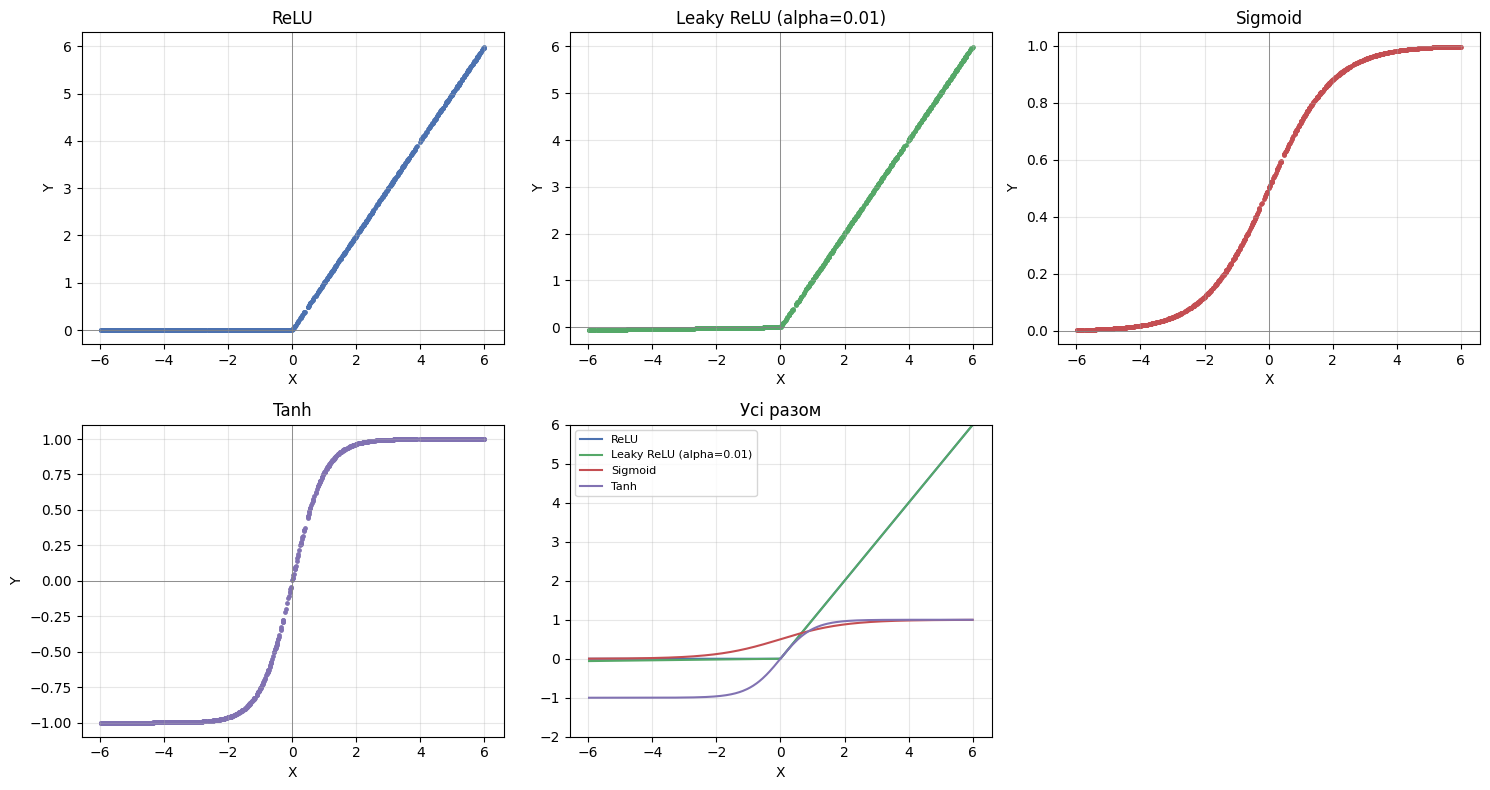

Діапазони виходу для X з [-6, 6]:
  ReLU                     min=  0.0000  max=  5.9977
  Leaky ReLU (alpha=0.01)  min= -0.0597  max=  5.9977
  Sigmoid                  min=  0.0025  max=  0.9975
  Tanh                     min= -1.0000  max=  1.0000

Що відбувається при x = -5: {'ReLU': 0.0, 'Leaky ReLU (alpha=0.01)': -0.05, 'Sigmoid': 0.0067, 'Tanh': -0.9999}


In [9]:
gen = torch.Generator().manual_seed(SEED)
x_act = torch.rand(1000, generator=gen) * 12 - 6        # 1000 випадкових X з [-6, 6]

activations = {
    "ReLU": torch.nn.ReLU(),
    "Leaky ReLU (alpha=0.01)": torch.nn.LeakyReLU(0.01),
    "Sigmoid": torch.nn.Sigmoid(),
    "Tanh": torch.nn.Tanh(),
}
y_act = {name: f(x_act) for name, f in activations.items()}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for ax, (name, y), col in zip(axes.flat, y_act.items(), colors):
    ax.scatter(x_act.numpy(), y.numpy(), s=6, color=col)
    ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
    ax.set_title(name); ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.grid(alpha=0.3)

ax = axes.flat[4]
order = torch.argsort(x_act)
for (name, y), col in zip(y_act.items(), colors):
    ax.plot(x_act[order].numpy(), y[order].numpy(), label=name, color=col)
ax.set_title("Усі разом"); ax.set_xlabel("X"); ax.set_ylim(-2, 6); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes.flat[5].axis("off")
plt.tight_layout(); plt.show()

print("Діапазони виходу для X з [-6, 6]:")
for name, y in y_act.items():
    print(f"  {name:24s} min={y.min().item():8.4f}  max={y.max().item():8.4f}")
print("\nЩо відбувається при x = -5:", {n: round(float(f(torch.tensor(-5.0))), 4) for n, f in activations.items()})

**Що видно на графіках.**

- **ReLU**: для x < 0 завжди 0, для x > 0 дорівнює x. Діапазон [0, +∞). Обчислюється дешево і не «насичується» праворуч (градієнт 1), але для від'ємних входів градієнт нульовий, тому нейрон може «померти».
- **Leaky ReLU** (α = 0.01): те саме, але зліва залишається маленький нахил (при x = −5 вихід −0.05, мінімум на вибірці −0.0597). Градієнт ніколи не рівний нулю. На спільному графіку лінії ReLU і Leaky ReLU майже збігаються, бо різниця зліва лише соті частки.
- **Sigmoid**: S-подібна крива, вихід лежить в (0, 1) (на вибірці від 0.0025 до 0.9975). Наприкінці крива пласка, тобто градієнт майже нульовий («насичення»), і не центрована навколо нуля. Зручна на виході, коли потрібна ймовірність.
- **Tanh**: теж S-подібна, але вихід у (−1, 1) і центрована в нулі (при x = −5 вже −0.9999). Також насичується на краях, але вчиться зазвичай стабільніше за sigmoid.

Усі чотири нелінійні. Це важливо: якщо між `Linear`-шарами нічого не вставляти, то весь стек шарів схлопнеться в одну лінійну функцію, і глибина нічого не дасть. Саме активація дозволяє мережі наближати криві. Далі в лабі вибір активації теж вплинув на результат: Tanh на Ames виявився помітно гіршим за ReLU.

#### Питання 6. Звідки береться кількість параметрів нейромережі після 3.3?

In [10]:
n_features_demo = cal_xtr.shape[1]    # 7 ознак після feature engineering
demo_nn = torch.nn.Sequential(
    torch.nn.Linear(n_features_demo, 64), torch.nn.ReLU(),
    torch.nn.Linear(64, 32), torch.nn.ReLU(),
    torch.nn.Linear(32, 1),
)
print(demo_nn, "\n")
rows, total = [], 0
for name, p in demo_nn.named_parameters():
    rows.append({"параметр": name, "форма": tuple(p.shape), "кількість": p.numel()})
    total += p.numel()
rows.append({"параметр": "РАЗОМ", "форма": "", "кількість": total})
print(pd.DataFrame(rows).to_string(index=False))

print("\nПерерахунок руками:")
print(f"  шар 1: {n_features_demo}*64 + 64 = {n_features_demo*64 + 64}")
print(f"  шар 2: 64*32 + 32 = {64*32 + 32}")
print(f"  шар 3: 32*1 + 1   = {32*1 + 1}")
print(f"  сума: {n_features_demo*64 + 64 + 64*32 + 32 + 32 + 1}")
n_lin = n_features_demo + 1
print(f"Лінійна модель: {n_features_demo} ваг + 1 зсув = {n_lin}; відношення NN/лінійна = {total / n_lin:.0f}")

Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
) 

параметр    форма  кількість
0.weight  (64, 7)        448
  0.bias    (64,)         64
2.weight (32, 64)       2048
  2.bias    (32,)         32
4.weight  (1, 32)         32
  4.bias     (1,)          1
   РАЗОМ                2625

Перерахунок руками:
  шар 1: 7*64 + 64 = 512
  шар 2: 64*32 + 32 = 2080
  шар 3: 32*1 + 1   = 33
  сума: 2625
Лінійна модель: 7 ваг + 1 зсув = 8; відношення NN/лінійна = 328


**Відповідь.** Параметр це кожна вага і кожен зсув (bias), які навчаються. Шар `Linear(in, out)` має `in · out` ваг і `out` зсувів. Активація `ReLU` параметрів не має. Для мережі `7 → 64 → 32 → 1`:

- шар 1: 7 · 64 + 64 = 512
- шар 2: 64 · 32 + 32 = 2080
- шар 3: 32 · 1 + 1 = 33
- разом: 512 + 2080 + 33 = **2625**

У таблиці вище це видно по рядках: `0.weight` 448 + `0.bias` 64 + `2.weight` 2048 + `2.bias` 32 + `4.weight` 32 + `4.bias` 1 = 2625. Лінійна модель має 7 ваг і 1 зсув, тобто 8 параметрів, і нейромережа виходить у ≈ 328 разів «більшою» (у демо кажуть «~330»). Це корисно усвідомлювати: чим більше параметрів відносно кількості рядків, тим вищий ризик перенавчання. У демо 12 384 навчальні рядки на 2625 параметрів це ще нормально, а в моїй лабі (874 рядки і до 88 тисяч параметрів) вийде зовсім інакше.

#### Питання 7. Чи оптимально вибрано кількість епох у 3.5?

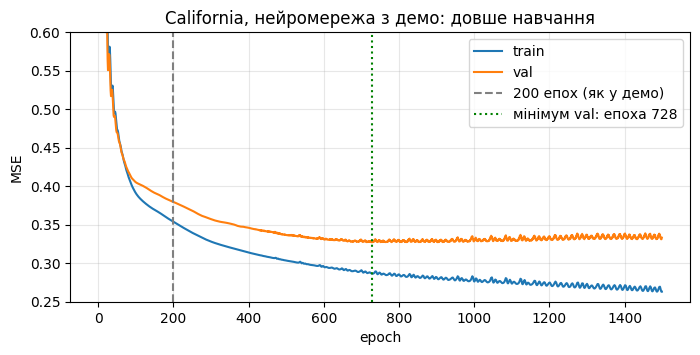

200 епох (як у демо)         val_MSE=0.3798  train_MSE=0.3542 | test: MSE=0.3752 MAE=0.4330 R2=0.7264
епоха 728 (мінімум val)      val_MSE=0.3273  train_MSE=0.2867 | test: MSE=0.3314 MAE=0.3985 R2=0.7583
1500 епох                    val_MSE=0.3332  train_MSE=0.2630 | test: MSE=0.3389 MAE=0.4054 R2=0.7528


In [11]:
# Ті самі налаштування, що в 3.5 демо (Adam, lr=0.01, повний батч), тільки епох більше - 1500 замість 200.
def train_cal_nn(epochs):
    set_seed()
    model = torch.nn.Sequential(
        torch.nn.Linear(n_features_demo, 64), torch.nn.ReLU(),
        torch.nn.Linear(64, 32), torch.nn.ReLU(),
        torch.nn.Linear(32, 1),
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = torch.nn.MSELoss()
    tr, va, snaps = [], [], {}
    for epoch in range(epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(cal_xtr), cal_ytr); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr.append(loss.item()); va.append(loss_fn(model(cal_xva), cal_yva).item())
        if va[-1] == min(va):
            snaps["best"] = {k: v.clone() for k, v in model.state_dict().items()}
        if epoch + 1 == 200:
            snaps["ep200"] = {k: v.clone() for k, v in model.state_dict().items()}
    snaps["last"] = {k: v.clone() for k, v in model.state_dict().items()}
    return model, tr, va, snaps

cal_nn, cal_tr, cal_va, snaps = train_cal_nn(1500)
best_ep = int(np.argmin(cal_va))

plt.figure(figsize=(8, 3.5))
plt.plot(cal_tr, label="train"); plt.plot(cal_va, label="val")
plt.axvline(200, color="gray", ls="--", label="200 епох (як у демо)")
plt.axvline(best_ep, color="green", ls=":", label=f"мінімум val: епоха {best_ep + 1}")
plt.ylim(0.25, 0.6); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("California, нейромережа з демо: довше навчання")
plt.legend(); plt.grid(alpha=0.3); plt.show()

for label, key in [("200 епох (як у демо)", "ep200"), (f"епоха {best_ep + 1} (мінімум val)", "best"), ("1500 епох", "last")]:
    cal_nn.load_state_dict(snaps[key]); cal_nn.eval()
    with torch.no_grad():
        p = cal_nn(cal_xte).cpu().numpy().ravel()
    m = calc_metrics(cal_y_test, p)
    ep_idx = {"ep200": 199, "best": best_ep, "last": 1499}[key]
    print(f"{label:28s} val_MSE={cal_va[ep_idx]:.4f}  train_MSE={cal_tr[ep_idx]:.4f} | test: MSE={m['MSE']:.4f} MAE={m['MAE']:.4f} R2={m['R2']:.4f}")

**Відповідь: ні, 200 епох замало.** У демо на 200-й епосі val MSE дорівнює 0.3798 і ще помітно падає, тобто крива не вийшла на плато і модель недотренована. Коли я залишив усе як є (Adam, `lr=0.01`, той самий seed), але навчав 1500 епох, то картина така:

| момент | val MSE | train MSE | test MSE | test MAE | test R² |
|---|---|---|---|---|---|
| 200 епох (як у демо) | 0.3798 | 0.3542 | 0.3752 | 0.4330 | 0.7264 |
| епоха 728 (мінімум val) | **0.3273** | 0.2867 | 0.3314 | 0.3985 | **0.7583** |
| 1500 епох | 0.3332 | 0.2630 | 0.3389 | 0.4054 | 0.7528 |

Мінімум val досягається приблизно на 730-й епосі. Після нього val-крива вже не падає й трохи гойдається вгору, а train далі зменшується (0.2867 → 0.2630). Це початок перенавчання. Тобто оптимум десь між 700 і 1000 епохами, а не 200. Вибір цієї точки зроблений за val, а test його підтверджує: R² 0.7583 проти 0.7264, виграш ≈ 0.03. Правильний спосіб не вгадувати число епох: вчити з запасом і зупинятися за val (early stopping) або зберігати ваги найкращої епохи.

---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі — задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** — 21 613 продажів будинків (Вашингтон, 2014–2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) — вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** — 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** — 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** — 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** — 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3–9). Усі ознаки — хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** — 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) — доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** — 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** — 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку — гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** — 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак — хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) — вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** — 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки — фізичні виміри, окрім `sex`.

Решта (2–5, 7–8, 10) вантажаться напряму — `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 — це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи — `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [12]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Споденюк Володимир Вікторович"

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])

Ваш датасет (#8): Ames House Prices


Хеш від мого ПІБ дає індекс 7, тобто **мій датасет — #8 Ames House Prices**: 1 460 будинків із міста Еймс (штат Айова), 79 ознак (площі, якість, рік побудови, район, стан підвалу й гаража тощо). Таргет — `SalePrice`, ціна продажу в доларах. Це регресія, причому з великою кількістю категоріальних ознак, тож буде багато роботи з пропусками та кодуванням.

---
## 2. Що потрібно зробити

Нижче — загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача — повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) — рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) — і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) — **якщо вони є**. Немає пропусків — так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних — capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) — **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) — **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

#### 2.1.1. Завантаження датасету і перетворення на DataFrame

Беру датасет із Hugging Face (`t22000t/house-prices-tabular`) і складаю всі спліти в одну таблицю, бо розбивати на train/val/test я буду сам. Якщо репозиторій з якоїсь причини не завантажується, ноутбук бере резервну копію тих самих даних Ames (Kaggle `train.csv`, 1 460 рядків), щоб Run All не падав. У цьому датасеті «NA» в категоріальних колонках означає «такої речі в будинку немає» (немає басейну, гаража тощо), але pandas читає «NA» як пропуск. Далі це важливо.

In [13]:
HF_REPO_ID = "t22000t/house-prices-tabular"
AMES_CSV_FALLBACK = ("https://raw.githubusercontent.com/Shitao-zz/"
                     "Kaggle-House-Prices-Advanced-Regression-Techniques/master/input/train.csv")
TARGET = "SalePrice"

def load_ames():
    try:
        ds = load_dataset(HF_REPO_ID)
        df = pd.concat([ds[k].to_pandas() for k in ds.keys()], ignore_index=True)
        assert TARGET in df.columns, "в датасеті нема колонки SalePrice"
        source = f"Hugging Face: {HF_REPO_ID}, спліти {list(ds.keys())}"
    except Exception as e:
        print(f"HF не вдалося завантажити ({type(e).__name__}) -> беру резервний CSV")
        df = pd.read_csv(AMES_CSV_FALLBACK)
        source = "резервне джерело: Kaggle House Prices train.csv (той самий Ames)"
    df = df[df[TARGET].notna()].copy()                 # рядки без ціни нам не потрібні
    if "Id" in df.columns:
        df = df.drop(columns="Id")                     # Id - просто номер рядка
    text_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    df[text_cols] = df[text_cols].replace("NA", np.nan)   # якщо "NA" лишився рядком - зводимо до справжнього пропуску
    return df.reset_index(drop=True), source

ames_df, ames_source = load_ames()
print("Джерело:", ames_source)
print("Загальний розмір таблиці:", ames_df.shape)

HF не вдалося завантажити (FileNotFoundError) -> беру резервний CSV
Джерело: резервне джерело: Kaggle House Prices train.csv (той самий Ames)
Загальний розмір таблиці: (1460, 80)


#### 2.1.2. Спліт train / val / test

Ділю дані 60 / 20 / 20 з `random_state=SEED` **одразу після завантаження**, до будь-якого аналізу. Причина — data leakage: якщо спочатку порахувати медіани, кореляції чи пороги викидів на всій таблиці, то інформація про val і test непомітно потрапляє в мої рішення, і тоді оцінка на test стає занадто оптимістичною. Тому все, що «вчиться» з даних (медіани, мода, kNN-імпутер, mean/std для стандартизації, список one-hot колонок), я рахую тільки на train, а на val і test лише застосовую. Val потрібен для вибору архітектури та гіперпараметрів, test — щоб один раз наприкінці чесно порівняти моделі.

In [14]:
train_df, temp_df = train_test_split(ames_df, test_size=0.4, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

# Копії «сирих» спліт-таблиць: знадобляться, щоб перевірити весь препроцесинг і для Gradio-застосунку
raw_train, raw_val, raw_test = train_df.copy(), val_df.copy(), test_df.copy()

print(f"Розмір навчальної вибірки (train): {train_df.shape}")
print(f"Розмір валідаційної вибірки (val): {val_df.shape}")
print(f"Розмір тестової вибірки (test): {test_df.shape}")

Розмір навчальної вибірки (train): (876, 80)
Розмір валідаційної вибірки (val): (292, 80)
Розмір тестової вибірки (test): (292, 80)


#### 2.1.3. Загальний огляд даних

Дивлюсь тільки на `train_df`, val і test не чіпаю.

In [15]:
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
314,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2006,WD,Normal,178000
442,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,162900
319,80,RL,NaN,14115,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,187500
767,50,RL,75.0,12508,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,Shed,1300,7,2008,WD,Normal,160000
756,60,RL,68.0,10769,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,212000


In [16]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 876 entries, 314 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     876 non-null    int64  
 1   MSZoning       876 non-null    str    
 2   LotFrontage    709 non-null    float64
 3   LotArea        876 non-null    int64  
 4   Street         876 non-null    str    
 5   Alley          58 non-null     str    
 6   LotShape       876 non-null    str    
 7   LandContour    876 non-null    str    
 8   Utilities      876 non-null    str    
 9   LotConfig      876 non-null    str    
 10  LandSlope      876 non-null    str    
 11  Neighborhood   876 non-null    str    
 12  Condition1     876 non-null    str    
 13  Condition2     876 non-null    str    
 14  BldgType       876 non-null    str    
 15  HouseStyle     876 non-null    str    
 16  OverallQual    876 non-null    int64  
 17  OverallCond    876 non-null    int64  
 18  YearBuilt      876 non-

In [17]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,876.0,57.808219,43.687092,20.0,20.00,50.0,70.00,190.0
LotFrontage,709.0,69.747532,26.157493,21.0,59.00,68.0,80.00,313.0
LotArea,876.0,10789.401826,12129.787810,1300.0,7466.25,9528.0,11515.50,215245.0
OverallQual,876.0,6.100457,1.368695,1.0,5.00,6.0,7.00,10.0
OverallCond,876.0,5.560502,1.109849,1.0,5.00,5.0,6.00,9.0
YearBuilt,876.0,1970.731735,30.820883,1872.0,1952.75,1972.0,2001.00,2010.0
YearRemodAdd,876.0,1984.601598,20.933526,1950.0,1965.75,1994.0,2004.00,2010.0
MasVnrArea,874.0,103.935927,171.436303,0.0,0.00,0.0,169.50,1378.0
BsmtFinSF1,876.0,449.519406,463.462631,0.0,0.00,397.0,725.00,5644.0
BsmtFinSF2,876.0,42.158676,152.313830,0.0,0.00,0.0,0.00,1120.0


**Що помітно з огляду.**

- У train 876 рядків і 80 колонок (79 ознак і `SalePrice`; колонку `Id` я прибрав). Колонки змішані: числові (площі, роки, кількості) і текстові категорії (43 штуки).
- Масштаби дуже різні: `LotArea` у середньому ~10 800, `OverallQual` близько 6, роки ~1970. Значить, без стандартизації нейромережа й SGD працюватимуть погано.
- Ціна: середня ≈ 180 тис. $, медіана ≈ 165 тис. $, діапазон від 34.9 до 625 тис. $. Середня помітно вища за медіану, тобто розподіл скошений праворуч (докладніше в EDA).
- `MSSubClass` лежить як число (20, 30, 60, ...), але це код типу будинку, а не величина: «60» не вдвічі більше за «30». Тому я далі ставлюсь до нього як до категорії.
- Пропуски є в 19 колонках з 80. Про їхню природу нижче.

#### 2.1.4. Обробка пропусків

##### 2.1.4.1. Де і скільки пропусків

In [18]:
na = train_df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
na_table = pd.DataFrame({"пропусків": na, "% від train": (na / len(train_df) * 100).round(1)})
print("Колонок із пропусками:", len(na_table), "з", train_df.shape[1])
na_table

Колонок із пропусками: 19 з 80


,пропусків,% від train
PoolQC,872,99.5
MiscFeature,839,95.8
Alley,818,93.4
Fence,709,80.9
MasVnrType,509,58.1
FireplaceQu,420,47.9
LotFrontage,167,19.1
GarageType,46,5.3
GarageYrBlt,46,5.3
GarageFinish,46,5.3


##### 2.1.4.2. Більшість «пропусків» — це насправді «такого немає»

Колонок із пропусками багато, але перед тим як щось заповнювати, треба зрозуміти природу пропуску. Перевіряю гіпотезу з опису датасету: якщо пропуск у `PoolQC` означає «басейну нема», то він має збігатися з `PoolArea == 0`. Аналогічно для гаража, підвалу, каміна.

In [19]:
checks = {
    "PoolQC пропущено  <->  PoolArea == 0":        (train_df["PoolQC"].isna(),        train_df["PoolArea"] == 0),
    "FireplaceQu пропущено  <->  Fireplaces == 0":  (train_df["FireplaceQu"].isna(),   train_df["Fireplaces"] == 0),
    "GarageType пропущено  <->  GarageArea == 0":   (train_df["GarageType"].isna(),    train_df["GarageArea"] == 0),
    "GarageYrBlt пропущено  <->  GarageArea == 0":  (train_df["GarageYrBlt"].isna(),   train_df["GarageArea"] == 0),
    "BsmtQual пропущено  <->  TotalBsmtSF == 0":    (train_df["BsmtQual"].isna(),      train_df["TotalBsmtSF"] == 0),
    "MasVnrType пропущено  <->  MasVnrArea == 0":   (train_df["MasVnrType"].isna(),    train_df["MasVnrArea"].fillna(0) == 0),
}
for name, (a, b) in checks.items():
    print(f"{name:50s} збіг у {(a == b).mean() * 100:.1f}% рядків")

PoolQC пропущено  <->  PoolArea == 0               збіг у 100.0% рядків
FireplaceQu пропущено  <->  Fireplaces == 0        збіг у 100.0% рядків
GarageType пропущено  <->  GarageArea == 0         збіг у 100.0% рядків
GarageYrBlt пропущено  <->  GarageArea == 0        збіг у 100.0% рядків
BsmtQual пропущено  <->  TotalBsmtSF == 0          збіг у 100.0% рядків
MasVnrType пропущено  <->  MasVnrArea == 0         збіг у 99.2% рядків


**Результат.** Усі п'ять перевірок збігаються на 100%, а для `MasVnrType` на 99.2% (кілька рядків із розбіжностями в самих даних, я їх не чіпаю): пропуск у `PoolQC` справді означає «басейну нема» (`PoolArea == 0`), у `FireplaceQu` «каміна нема» тощо. Для `MasVnrType` «None» (немає облицювання) pandas теж прочитав як пропуск, тому там аж 509 «пропусків». Для `Alley`, `Fence`, `MiscFeature` такої перевірочної колонки нема, але за описом датасету там теж «NA = нема». Значить, у цих колонках дані не втрачені, а навпаки, пропуск несе інформацію. Якби я заповнив їх медіаною або модою, то стер би різницю між «нема басейну» і «є басейн».

##### 2.1.4.3. Справжні пропуски і чим їх заповнювати

Лишається кілька колонок, де пропуск — це справді відсутнє значення:

- **`LotFrontage`** (довжина вулиці перед ділянкою) — найбільша проблема, пропущено в кожному п'ятому будинку. Тут використаю kNN-імпутацію, як у демо, але спершу перевірю, що вона справді краща за прості варіанти.
- **`Electrical`** — один пропуск на весь train, заповню модою.
- **`MasVnrArea`** — пропуск разом із `MasVnrType`, тобто облицювання нема, площа 0.
- **`GarageYrBlt`** — рік побудови гаража є пропуском там, де гаража нема. Заповню роком побудови будинку, а потім ця колонка все одно піде під видалення як дубль `YearBuilt` (див. 2.1.7).

Для категоріальних «такого немає» ставлю окрему категорію `"None"`: це інформація, а не втрата. `MSSubClass` — це числовий код типу будинку (20, 30, 60...), а не величина, тому одразу роблю його рядком.

Для `LotFrontage` порівняю способи на відомих значеннях train: ховаю частину відомих значень, відновлюю їх кожним методом і міряю RMSE (у футах). Медіана і kNN навчаються лише на train.

In [20]:
CAT_COLS = [c for c in train_df.columns if not pd.api.types.is_numeric_dtype(train_df[c])] + ["MSSubClass"]
CAT_COLS = sorted(set(CAT_COLS))
ELECTRICAL_MODE = train_df["Electrical"].mode()[0]          # рахуємо тільки на train

def fill_simple(d):
    """Заповнення пропусків, які не потребують моделі. Усі константи взяті з train."""
    d = d.copy()
    d["MSSubClass"] = d["MSSubClass"].astype(str)
    for c in CAT_COLS:
        if c == "Electrical":
            d[c] = d[c].fillna(ELECTRICAL_MODE)
        else:
            d[c] = d[c].fillna("None")                      # "такого нема" - це окрема категорія
    d["MasVnrArea"] = d["MasVnrArea"].fillna(0)
    d["GarageYrBlt"] = d["GarageYrBlt"].fillna(d["YearBuilt"])
    return d

train_df, val_df, test_df = fill_simple(train_df), fill_simple(val_df), fill_simple(test_df)

# --- порівнюємо способи заповнення LotFrontage на відомих значеннях train ---
LF_PREDICTORS = [c for c in train_df.select_dtypes(include=[np.number]).columns if c not in (TARGET, "LotFrontage")]
known = train_df[train_df["LotFrontage"].notna()]

def rmse(a, b):
    return float(np.sqrt(((a - b) ** 2).mean()))

scores = {"медіана по всьому train": [], "медіана по району (Neighborhood)": [],
          "kNN (k=5), ознаки як є": [], "kNN (k=5), ознаки стандартизовані": []}
for tr_idx, te_idx in RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEED).split(known):
    A, B = known.iloc[tr_idx], known.iloc[te_idx]
    scores["медіана по всьому train"].append(rmse(B["LotFrontage"], A["LotFrontage"].median()))
    by_nb = A.groupby("Neighborhood")["LotFrontage"].median()
    scores["медіана по району (Neighborhood)"].append(
        rmse(B["LotFrontage"], B["Neighborhood"].map(by_nb).fillna(A["LotFrontage"].median())))
    m = KNeighborsRegressor(n_neighbors=5).fit(A[LF_PREDICTORS], A["LotFrontage"])
    scores["kNN (k=5), ознаки як є"].append(rmse(B["LotFrontage"], m.predict(B[LF_PREDICTORS])))
    m = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)).fit(A[LF_PREDICTORS], A["LotFrontage"])
    scores["kNN (k=5), ознаки стандартизовані"].append(rmse(B["LotFrontage"], m.predict(B[LF_PREDICTORS])))

lf_cmp = pd.DataFrame({"RMSE, фути (середнє)": {k: np.mean(v) for k, v in scores.items()},
                       "std по фолдах": {k: np.std(v) for k, v in scores.items()}}).round(2)
print(f"std самої LotFrontage на train: {known['LotFrontage'].std():.1f} фут  (це «похибка» заповнення константою-середнім)")
lf_cmp

std самої LotFrontage на train: 26.2 фут  (це «похибка» заповнення константою-середнім)


,"RMSE, фути (середнє)",std по фолдах
медіана по всьому train,25.73,5.03
медіана по району (Neighborhood),23.50,5.57
"kNN (k=5), ознаки як є",20.86,4.47
"kNN (k=5), ознаки стандартизовані",22.72,4.38


**Що показала перевірка.** `LotFrontage` погано передбачувана: std самої колонки 26.2 фута, а заповнення однією медіаною дає помилку 25.7 фута (майже та сама величина, тобто медіана практично нічого не знає про конкретний будинок). Медіана по району трохи краща (23.5). Найкращий kNN на ознаках «як є»: **20.9 фута**, це приблизно на 19% точніше за медіану. kNN зі стандартизованими ознаками виявився гіршим (22.7). Мабуть, тому, що при стандартизації десятки не пов'язаних із вулицею колонок (`MoSold`, `YrSold`, ...) отримують таку саму вагу, як і площі ділянки, а без стандартизації відстань визначають саме великі за масштабом площі, які і пов'язані з довжиною вулиці перед ділянкою. Тому беру kNN (k=5) без масштабування.

Виграш помірний (по фолдах std ≈ 4.5 фута), але це найкраще з перевіреного, і воно відповідає тому, що ми робили в демо. На відміну від демо, я не даю kNN дивитись на `SalePrice`: на новому будинку ціни ще нема.

In [21]:
# Фінальний вибір: kNN (k=5). Навчаємо тільки на train, таргет SalePrice у предикторах НЕ використовуємо.
knn_lf = KNeighborsRegressor(n_neighbors=5).fit(known[LF_PREDICTORS], known["LotFrontage"])

def impute_lotfrontage(d):
    d = d.copy()
    mask = d["LotFrontage"].isna()
    if mask.any():
        d.loc[mask, "LotFrontage"] = knn_lf.predict(d.loc[mask, LF_PREDICTORS])
    return d

train_df, val_df, test_df = impute_lotfrontage(train_df), impute_lotfrontage(val_df), impute_lotfrontage(test_df)

print("Залишилось пропусків (train):", train_df.isna().sum().sum())
print("Залишилось пропусків (val):  ", val_df.isna().sum().sum())
print("Залишилось пропусків (test): ", test_df.isna().sum().sum())

Залишилось пропусків (train): 0
Залишилось пропусків (val):   0
Залишилось пропусків (test):  0


#### 2.1.5. EDA

Працюю тільки з train.

##### 2.1.5.1. Таргет `SalePrice`

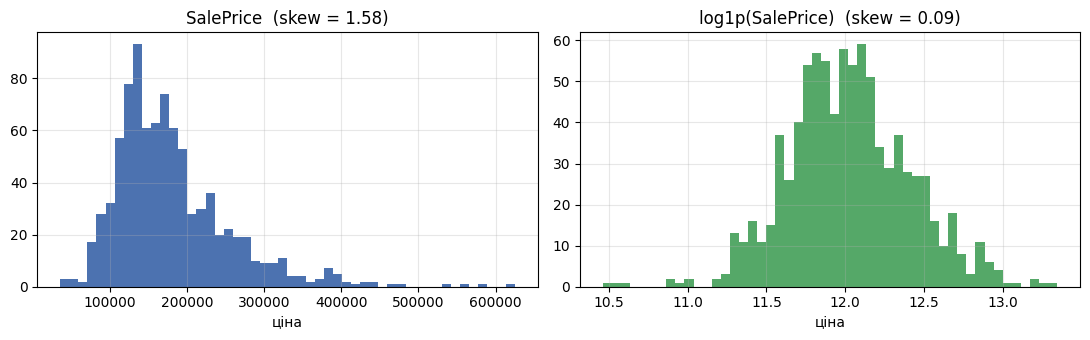

Найбільші значення таргету (чи є «стеля»/capping):
SalePrice
625000    1
582933    1
555000    1
538000    1
475000    1
Name: count, dtype: int64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(train_df[TARGET], bins=50, color="#4C72B0"); axes[0].set_title(f"SalePrice  (skew = {skew(train_df[TARGET]):.2f})")
axes[1].hist(np.log1p(train_df[TARGET]), bins=50, color="#55A868"); axes[1].set_title(f"log1p(SalePrice)  (skew = {skew(np.log1p(train_df[TARGET])):.2f})")
for ax in axes: ax.set_xlabel("ціна"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Найбільші значення таргету (чи є «стеля»/capping):")
print(train_df[TARGET].value_counts().sort_index(ascending=False).head(5))

##### 2.1.5.2. Гістограми числових ознак

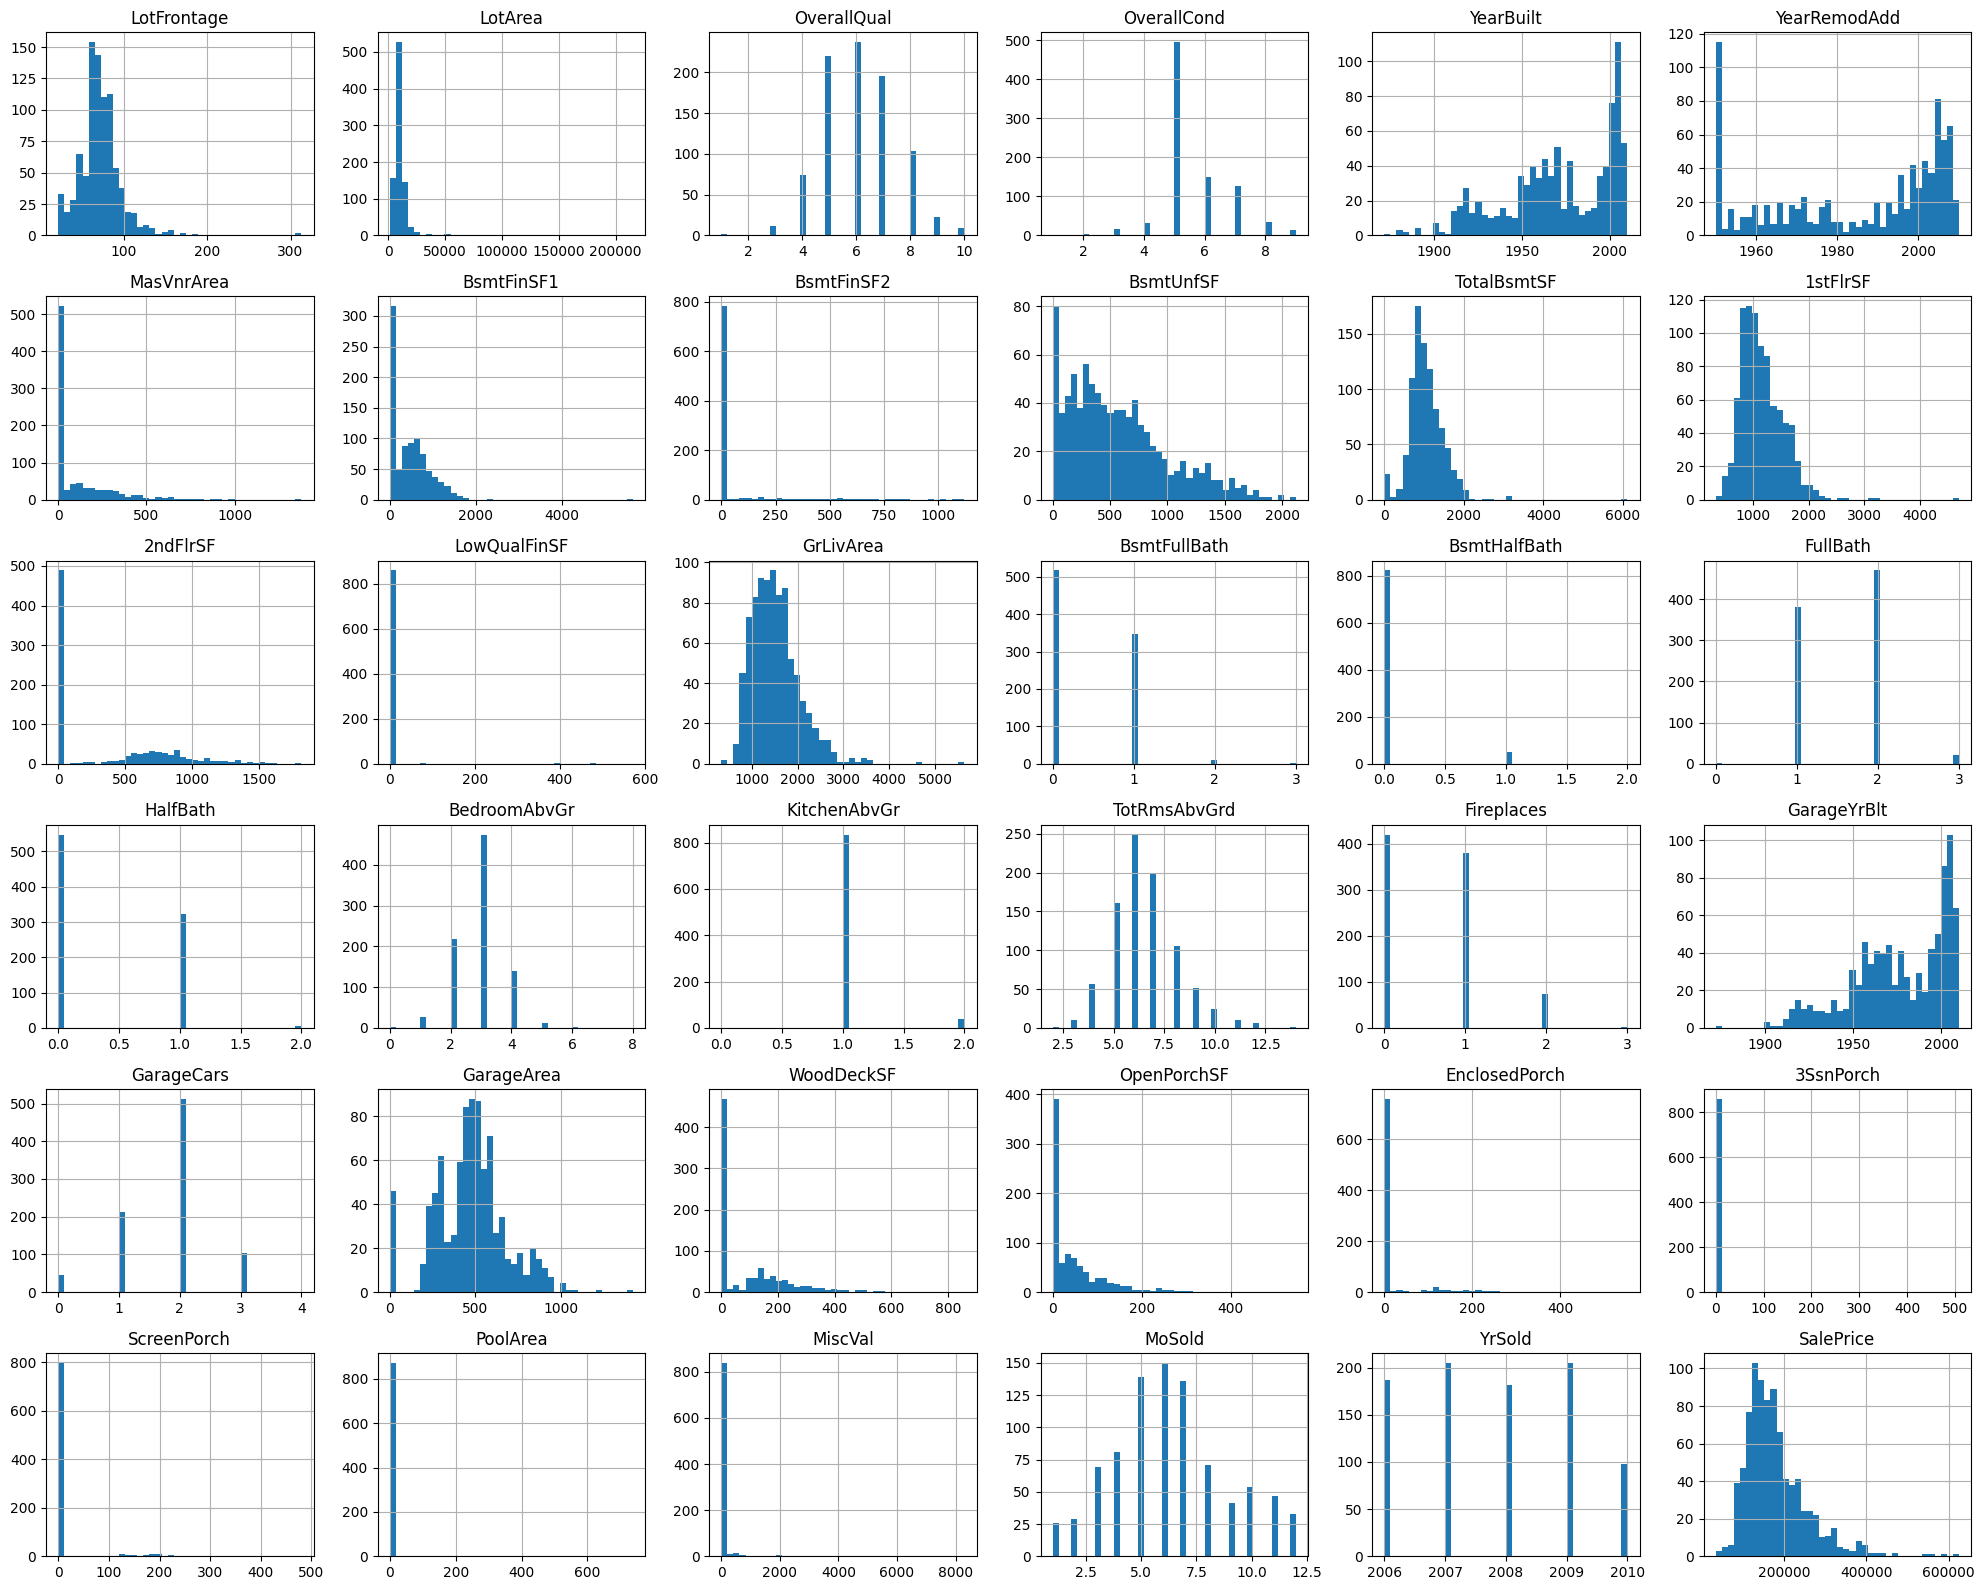

Найбільш скошені числові ознаки (skewness):
MiscVal          17.29
PoolArea         15.49
LotArea          11.04
3SsnPorch         9.59
LowQualFinSF      9.21
BsmtFinSF2        4.33
KitchenAbvGr      4.05
ScreenPorch       4.02
BsmtHalfBath      3.88
EnclosedPorch     3.39

YearRemodAdd == 1950: 112 рядків (13% train), з них збудовані до 1950: 104; мінімум колонки = 1950


In [23]:
num_cols_eda = [c for c in train_df.select_dtypes(include=[np.number]).columns]
train_df[num_cols_eda].hist(bins=40, figsize=(20, 16))
plt.tight_layout(); plt.show()

sk = train_df[num_cols_eda].drop(columns=TARGET).apply(lambda s: skew(s.dropna()))
print("Найбільш скошені числові ознаки (skewness):")
print(sk.sort_values(ascending=False).head(10).round(2).to_string())

n1950 = int((train_df["YearRemodAdd"] == 1950).sum())
n1950_old = int(((train_df["YearRemodAdd"] == 1950) & (train_df["YearBuilt"] < 1950)).sum())
print(f"\nYearRemodAdd == 1950: {n1950} рядків ({n1950 / len(train_df) * 100:.0f}% train), з них збудовані до 1950: {n1950_old}; мінімум колонки = {train_df['YearRemodAdd'].min()}")

**Що впадає в око.**

1. **Таргет скошений праворуч.** Skewness `SalePrice` ≈ 1.6, а після `log1p` ≈ 0.1, тобто розподіл стає майже симетричним. Тому в 2.2 я тренуватиму моделі на логарифмі ціни. «Стелі» (capping) на таргеті нема: найбільші значення всі різні (625 000, 582 933, 555 000, ...), піку біля максимуму немає.
2. **Багато ознак із великою кількістю нулів**: `MasVnrArea`, `BsmtFinSF1/2`, `2ndFlrSF`, `WoodDeckSF`, веранди, `PoolArea`, `MiscVal`, `LowQualFinSF`. Нуль тут означає «такої частини будинку нема», це не помилка. `PoolArea`, `MiscVal`, `3SsnPorch`, `LowQualFinSF` майже завжди нулі, тож для моделі вони практично константи.
3. **Довгі праві хвости в площах**: `LotArea` (skewness ≈ 11), `BsmtFinSF2`, `EnclosedPorch`, `ScreenPorch`. Це кандидати на `log1p`.
4. **Capping у `YearRemodAdd`.** На гістограмі видно високий стовпчик на 1950. Це нижня межа колонки: у 112 рядках (13% train) рік ремонту рівно 1950, і майже всі вони (104) збудовані до 1950. Тобто для старих будинків без даних про ремонт у цю колонку записано 1950, а не справжню дату. Це «обрізана» ознака; видаляти рядки через неї не буду, але пам'ятаю, що `RemodAge` для цих будинків неточний.
5. Дискретні ознаки (`OverallQual`, `FullBath`, `GarageCars`, ...) мають кілька значень, їх логарифмувати нема сенсу.

##### 2.1.5.3. Кореляції

Матриця 37 числових колонок була б нечитабельною, тому малюю її для 12 ознак, що найсильніше корелюють з таргетом, а пари з високою кореляцією між собою (мультиколінеарність) шукаю окремо по всіх колонках.

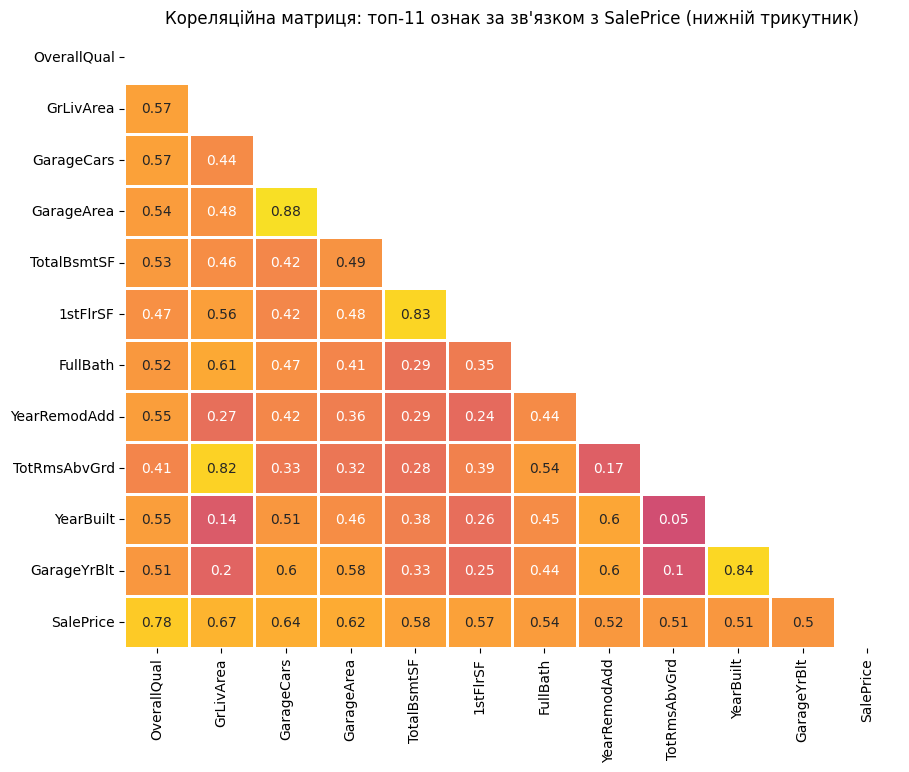

Кореляція з таргетом (топ-12):
OverallQual     0.782
GrLivArea       0.666
GarageCars      0.636
GarageArea      0.615
TotalBsmtSF     0.577
1stFlrSF        0.574
FullBath        0.535
YearRemodAdd    0.519
TotRmsAbvGrd    0.511
YearBuilt       0.506
GarageYrBlt     0.496
Fireplaces      0.460

Пари ознак із |кореляцією| > 0.75 (мультиколінеарність):
  GarageCars     <-> GarageArea     0.88
  YearBuilt      <-> GarageYrBlt    0.84
  TotalBsmtSF    <-> 1stFlrSF       0.83
  GrLivArea      <-> TotRmsAbvGrd   0.82


In [24]:
corr_all = train_df[num_cols_eda].corr()
top = corr_all[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(11).index.tolist() + [TARGET]

corr = train_df[top].corr().round(2)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, center=0, cmap="plasma", lw=2, annot=True, cbar=False, ax=ax)
plt.title("Кореляційна матриця: топ-11 ознак за зв'язком з SalePrice (нижній трикутник)")
plt.show()

print("Кореляція з таргетом (топ-12):")
print(corr_all[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).head(12).round(3).to_string())

feat_corr = corr_all.drop(index=TARGET, columns=TARGET).abs()
pairs = [(a, b, feat_corr.loc[a, b]) for i, a in enumerate(feat_corr.columns) for b in feat_corr.columns[i + 1:] if feat_corr.loc[a, b] > 0.75]
print("\nПари ознак із |кореляцією| > 0.75 (мультиколінеарність):")
for a, b, v in sorted(pairs, key=lambda t: -t[2]):
    print(f"  {a:14s} <-> {b:14s} {v:.2f}")

**Висновки.**

- **З таргетом найсильніше корелює `OverallQual` (0.78)**, далі `GrLivArea` (0.67), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.58), `1stFlrSF` (0.57). Якість і площа визначають ціну, що очікувано.
- **Мультиколінеарність, чотири пари з кореляцією > 0.75:** `GarageCars`–`GarageArea` (0.88), `YearBuilt`–`GarageYrBlt` (0.84, ймовірно, частково тому, що я заповнив `GarageYrBlt` роком побудови), `TotalBsmtSF`–`1stFlrSF` (0.83), `GrLivArea`–`TotRmsAbvGrd` (0.82). У парі ознаки несуть майже ту саму інформацію: ваги лінійної моделі стають нестабільними (вплив ділиться між двома колонками довільно), а нейромережа отримує зайві входи. Це привід об'єднати або прибрати частину ознак у 2.1.7.

#### 2.1.6. Обробка викидів

Тут головне питання — звідки взявся викид. Дивлюсь на залежність ціни від житлової площі `GrLivArea`: це найсильніша після `OverallQual` числова ознака.

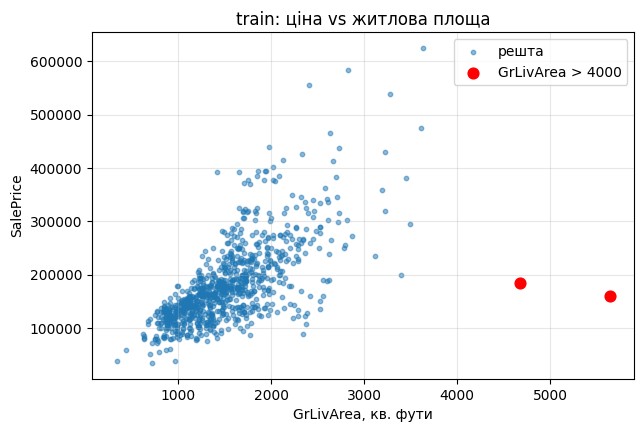

,GrLivArea,OverallQual,SaleCondition,SaleType,SalePrice
523,4676,10,Partial,New,184750
1298,5642,10,Partial,New,160000


In [25]:
big = (train_df["GrLivArea"] > 4000)
plt.figure(figsize=(7, 4.5))
plt.scatter(train_df.loc[~big, "GrLivArea"], train_df.loc[~big, TARGET], s=10, alpha=0.5, label="решта")
plt.scatter(train_df.loc[big, "GrLivArea"], train_df.loc[big, TARGET], s=60, color="red", label="GrLivArea > 4000")
plt.xlabel("GrLivArea, кв. фути"); plt.ylabel("SalePrice"); plt.title("train: ціна vs житлова площа")
plt.legend(); plt.grid(alpha=0.3); plt.show()

train_df.loc[big, ["GrLivArea", "OverallQual", "SaleCondition", "SaleType", TARGET]]

In [26]:
print("LotFrontage > 150 фут у train:", int((train_df["LotFrontage"] > 150).sum()), "рядків; максимум =", train_df["LotFrontage"].max())
print("LotArea: максимум =", train_df["LotArea"].max(), "| 99-й перцентиль =", round(train_df["LotArea"].quantile(0.99)))

LotFrontage > 150 фут у train: 10 рядків; максимум = 313.0
LotArea: максимум = 215245 | 99-й перцентиль = 50980


**Що тут не так.** Два будинки (рядки 523 і 1298) мають величезну житлову площу, 4676 і 5642 кв. фути, але коштують лише 184 750 $ і 160 000 $, тоді як решта великих будинків коштують у рази більше. Вони мають `OverallQual = 10`, `SaleCondition = Partial` і `SaleType = New`. Тобто це нові будинки, які продавались ще недобудованими (Partial), і зафіксована ціна не відповідає готовому будинку. Автор датасету теж радить прибирати будинки з `GrLivArea > 4000`. Це не «рідкісний, але справжній» випадок, а спотворений запис, який ламає головну залежність «більше площа, вища ціна». Для моделі з квадратичним loss дві такі точки сильно тягнуть пряму до себе.

Інші «великі» значення (`LotFrontage` понад 150 футів, `LotArea` до 215 тис. кв. футів при 99-му перцентилі ≈ 51 тис.) не схожі на помилки введення: це реальні великі ділянки. Видаляти їх не треба, для `LotArea` проблему розв'яже логарифм.

In [27]:
outlier_mask = (train_df["GrLivArea"] > 4000) & (train_df[TARGET] < 300_000)
print("Видаляємо з train рядків:", int(outlier_mask.sum()))
train_df = train_df[~outlier_mask].copy()          # викиди чистимо ТІЛЬКИ в train; val і test не чіпаємо
print("Розмір train після видалення:", train_df.shape)

Видаляємо з train рядків: 2
Розмір train після видалення: (874, 80)


**Підсумок по викидах і нестандартних значеннях:**

| що | рішення | чому |
|---|---|---|
| 2 будинки: `GrLivArea > 4000` і ціна < 300 тис. $ | **видалив з train** | недобудовані (Partial) нові будинки, ціна не відповідає площі |
| довгі хвости площ (`LotArea` та ін.) | **трансформую** (`log1p`) у 2.1.7.3 | реальні значення, але хвіст заважає; логарифм робитиму після підрахунку `TotalSF`, бо суми площ треба рахувати в сирих одиницях |
| `SalePrice` | **трансформую** (`log1p`) у 2.2.1 | скошений праворуч |
| великі ділянки (`LotFrontage` > 150, великий `LotArea`) | **залишаю** | схожі на реальні дані, не на помилки |
| `YearRemodAdd = 1950` (capping) | **залишаю** | це нижня межа колонки, а не викид; видаляти 13% рядків недоречно |

Викиди чищу тільки в train; val і test не чіпаю, щоб вони лишились чесним «дзеркалом» нових даних.

#### 2.1.7. Інженерія ознак

Тут кілька дрібних кроків: нові ознаки, прибирання дублів, логарифм для скошених ознак, кодування категорій і відсів майже константних колонок. Усі формули детерміновані (не статистики з даних), тому їх можна однаково застосовувати до train, val і test без витоку. Усе, що залежить від даних (список скошених ознак, набір one-hot колонок), визначаю по train.

##### 2.1.7.1. Нові ознаки

Площа, ванні й вік у датасеті розкидані по кількох колонках, які до того ж сильно корелюють між собою (див. 2.1.5.3). Об'єдную їх:

- `TotalSF` = підвал + 1-й поверх + 2-й поверх (загальна площа);
- `TotalBath` = повні ванни + 0.5 · напівванни (і на поверхах, і в підвалі);
- `HouseAge` = `YrSold − YearBuilt` і `RemodAge` = `YrSold − YearRemodAdd` (скільки років будинку і скільки минуло від ремонту на момент продажу — «вік» для моделі природніший за календарний рік).

In [28]:
def add_features(d):
    d = d.copy()
    d["TotalSF"] = d["TotalBsmtSF"] + d["1stFlrSF"] + d["2ndFlrSF"]
    d["TotalBath"] = d["FullBath"] + 0.5 * d["HalfBath"] + d["BsmtFullBath"] + 0.5 * d["BsmtHalfBath"]
    d["HouseAge"] = d["YrSold"] - d["YearBuilt"]
    d["RemodAge"] = d["YrSold"] - d["YearRemodAdd"]
    return d

train_df, val_df, test_df = add_features(train_df), add_features(val_df), add_features(test_df)

def c_t(col):
    return round(train_df[col].corr(train_df[TARGET]), 3)

print("Кореляція з SalePrice (train):")
for new, parts in [("TotalSF", ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea"]),
                   ("TotalBath", ["FullBath", "HalfBath", "BsmtFullBath"]),
                   ("HouseAge", ["YearBuilt"]), ("RemodAge", ["YearRemodAdd"])]:
    print(f"  {new:10s} {c_t(new):6.3f}   <- компоненти: " + ", ".join(f"{p} {c_t(p)}" for p in parts))
print("\nМін. HouseAge / RemodAge у train:", train_df["HouseAge"].min(), "/", train_df["RemodAge"].min())
print("Кореляція між новими ознаками:  TotalSF-GrLivArea =", round(train_df["TotalSF"].corr(train_df["GrLivArea"]), 2),
      "| HouseAge-RemodAge =", round(train_df["HouseAge"].corr(train_df["RemodAge"]), 2))

Кореляція з SalePrice (train):
  TotalSF     0.816   <- компоненти: TotalBsmtSF 0.637, 1stFlrSF 0.617, 2ndFlrSF 0.293, GrLivArea 0.708
  TotalBath   0.621   <- компоненти: FullBath 0.538, HalfBath 0.28, BsmtFullBath 0.237
  HouseAge   -0.508   <- компоненти: YearBuilt 0.507
  RemodAge   -0.522   <- компоненти: YearRemodAdd 0.52

Мін. HouseAge / RemodAge у train: 0 / 0
Кореляція між новими ознаками:  TotalSF-GrLivArea = 0.86 | HouseAge-RemodAge = 0.6


**Що вийшло.**

- `TotalSF` корелює з ціною на **0.816**, тобто сильніше за кожну зі своїх частин (`TotalBsmtSF` 0.637, `1stFlrSF` 0.617, `2ndFlrSF` 0.293) і навіть сильніше за `GrLivArea` (0.708). Об'єднана площа справді інформативніша за шматки.
- `TotalBath` (0.621) краща за `FullBath` (0.538), `HalfBath` (0.28) і `BsmtFullBath` (0.237).
- `HouseAge` (−0.508) і `RemodAge` (−0.522) за модулем майже такі самі, як `YearBuilt` (0.507) і `YearRemodAdd` (0.52). Тобто нової інформації тут нема, це лише зручніше формулювання: «вік будинку при продажу» замість календарного року, зі знаком мінус (старіший, отже дешевший). Перевага швидше в інтерпретації, ніж у точності.
- Від'ємних віків нема (мінімум 0 для обох), тож жодних «продано до побудови» у train немає.
- Нові ознаки теж корелюють між собою: `TotalSF`–`GrLivArea` 0.86, `HouseAge`–`RemodAge` 0.6. Це нормально, я не змушую себе мати абсолютно незалежні ознаки, але саме тому нижче прибираю старі компоненти.

##### 2.1.7.2. Прибираємо дублі

З пар, які сильно корелюють, лишаю одну ознаку (ту, що сильніше пов'язана з таргетом), або ту, що їх узагальнює:

| прибираю | чому |
|---|---|
| `GarageArea` | дублює `GarageCars` (0.88), а `GarageCars` сильніше корелює з ціною |
| `TotRmsAbvGrd` | дублює `GrLivArea` (0.82), а площа сильніше корелює з ціною |
| `GarageYrBlt` | майже копія `YearBuilt` (0.84); до того ж ми заповнювали його саме роком побудови |
| `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF` | усі три входять у `TotalSF` (до того ж `TotalBsmtSF` і `1stFlrSF` корелюють між собою на 0.83) |
| `FullBath`, `HalfBath`, `BsmtFullBath`, `BsmtHalfBath` | узагальнені в `TotalBath` |
| `YearBuilt`, `YearRemodAdd` | замінені на `HouseAge` і `RemodAge` (кореляція з ними рівно −1, це та сама інформація) |

`GrLivArea` і `TotalSF` теж корелюють (близько 0.86), але `TotalSF` містить підвал, якого в `GrLivArea` нема, тож залишаю обидві.

In [29]:
DROP_COLS = ["GarageArea", "TotRmsAbvGrd", "GarageYrBlt", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
             "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "YearBuilt", "YearRemodAdd"]

def drop_redundant(d):
    return d.drop(columns=DROP_COLS)

train_df, val_df, test_df = drop_redundant(train_df), drop_redundant(val_df), drop_redundant(test_df)
print("Колонок лишилось:", train_df.shape[1], "(разом з таргетом)")

Колонок лишилось: 72 (разом з таргетом)


##### 2.1.7.3. Логарифм для скошених ознак

З EDA видно, що площі (`LotArea`, `MasVnrArea`, `WoodDeckSF`, ...) мають довгий правий хвіст. Це реальні дані, а не помилки (бувають великі ділянки), тож видаляти їх небезпечно. Як у демо (1.7.4), для таких випадків краще трансформація: `log1p`. Беру ознаки, де skewness по модулю більша за 1, значень більше 20 (щоб не чіпати дискретні лічильники), і мінімум не менший за 0. Список визначаю по train. Таргет теж прологарифмую, але це вже в розділі 2.2, разом зі стандартизацією.

In [30]:
num_now = [c for c in train_df.select_dtypes(include=[np.number]).columns if c != TARGET]
sk_now = train_df[num_now].apply(lambda s: skew(s))
nuniq = train_df[num_now].nunique()
SKEWED = [c for c in num_now if abs(sk_now[c]) > 1 and nuniq[c] > 20 and train_df[c].min() >= 0]
print("Ознаки, до яких застосовуємо log1p:", SKEWED)
print("Skewness до:", sk_now[SKEWED].round(2).to_dict())

def log_transform(d):
    d = d.copy()
    for c in SKEWED:
        d[c] = np.log1p(d[c])
    return d

train_df, val_df, test_df = log_transform(train_df), log_transform(val_df), log_transform(test_df)
print("Skewness після:", {c: round(float(skew(train_df[c])), 2) for c in SKEWED})

Ознаки, до яких застосовуємо log1p: ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF2', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']
Skewness до: {'LotFrontage': 1.69, 'LotArea': 11.43, 'MasVnrArea': 2.24, 'BsmtFinSF2': 4.32, 'WoodDeckSF': 1.61, 'OpenPorchSF': 2.35, 'EnclosedPorch': 3.38, 'ScreenPorch': 4.01}
Skewness після: {'LotFrontage': -0.77, 'LotArea': 0.02, 'MasVnrArea': 0.44, 'BsmtFinSF2': 2.66, 'WoodDeckSF': 0.21, 'OpenPorchSF': -0.04, 'EnclosedPorch': 2.22, 'ScreenPorch': 2.92}


##### 2.1.7.4. Кодування категоріальних ознак

Нейромережа й `nn.Linear` працюють тільки з числами. Категорії кодую двома способами:

- **ординальні** шкали якості (`Ex > Gd > TA > Fa > Po`, плюс `None` = «немає») перетворюю на числа 0-5 — тут порядок має сенс, і це економить десятки колонок. Так само для `BsmtExposure`, `BsmtFinType1/2`, `GarageFinish`;
- **решта** (`Neighborhood`, `MSZoning`, `SaleType`, ...) — one-hot, бо порядку між ними нема. Набір колонок визначаю по train; якщо у val/test зустрінеться категорія, якої нема в train, усі її dummy просто будуть нулями.

In [31]:
QUAL_MAP = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ORDINAL_QUAL = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
ORDINAL_OTHER = {
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
}
ORDINAL_ALL = set(ORDINAL_QUAL) | set(ORDINAL_OTHER)
ONE_HOT_COLS = [c for c in CAT_COLS if c not in ORDINAL_ALL]

def encode(d):
    d = d.copy()
    for c in ORDINAL_QUAL:
        d[c] = d[c].map(QUAL_MAP)
    for c, mp in ORDINAL_OTHER.items():
        d[c] = d[c].map(mp)
    dummies = pd.get_dummies(d[ONE_HOT_COLS], dtype=float)
    return pd.concat([d.drop(columns=ONE_HOT_COLS), dummies], axis=1)

enc_train = encode(train_df)
ALL_ENCODED_COLS = [c for c in enc_train.columns if c != TARGET]
print("Ординальних колонок:", len(ORDINAL_ALL), "| one-hot вихідних колонок:", len(ONE_HOT_COLS))
print("Ознак після кодування (до відсіву):", len(ALL_ENCODED_COLS))
print("NaN після мапінгу ординальних у train:", int(enc_train[list(ORDINAL_ALL)].isna().sum().sum()))

Ординальних колонок: 14 | one-hot вихідних колонок: 30
Ознак після кодування (до відсіву): 242
NaN після мапінгу ординальних у train: 0


##### 2.1.7.5. Відсів майже константних колонок

Після one-hot з'явилося багато колонок, де майже всі значення однакові (наприклад, `Utilities_AllPub` або дуже рідкісні райони). З 874 рядків такі колонки практично нічого не дають, зате роздувають кількість ознак і ваг. Вибираю поріг так: колонка вилітає, якщо одне значення займає в train частку ≥ порогу. Пробую кілька порогів і дивлюсь на val-похибку простої лінійної регресії. `LinearRegression` із sklearn використовую тут тільки як швидкий інструмент для вибору порогу, усі фінальні моделі в роботі — на PyTorch.

In [32]:
from sklearn.linear_model import LinearRegression

y_tr_log = np.log1p(train_df[TARGET].values)
y_va_log = np.log1p(val_df[TARGET].values)
Xtr_enc = enc_train[ALL_ENCODED_COLS]
Xva_enc = encode(val_df).reindex(columns=ALL_ENCODED_COLS, fill_value=0.0)
top_share = Xtr_enc.apply(lambda s: s.value_counts(normalize=True).iloc[0])

rows = []
for thr in [0.95, 0.98, 0.99, 0.995, 1.01]:
    keep = top_share[top_share < thr].index.tolist()
    sc_tmp = StandardScaler().fit(Xtr_enc[keep])
    lr_tmp = LinearRegression().fit(sc_tmp.transform(Xtr_enc[keep]), y_tr_log)
    pred = lr_tmp.predict(sc_tmp.transform(Xva_enc[keep]))
    rows.append({"поріг": thr if thr < 1 else "не відсівати", "ознак лишилось": len(keep),
                 "val RMSE (log-ціна)": round(float(np.sqrt(((pred - y_va_log) ** 2).mean())), 4)})
pd.DataFrame(rows)

,поріг,ознак лишилось,val RMSE (log-ціна)
0,0.95,100,0.1303
1,0.98,145,0.1311
2,0.99,175,0.1180
3,0.995,193,0.1196
4,не відсівати,242,0.1220


**Що показала перевірка.** Найменша val-похибка при порозі 0.99: 0.1180 (175 ознак). При жорсткішому відсіві (0.95 і 0.98) вона гірша (0.130-0.131), а без відсіву (242 ознаки) 0.1220. Різниці близько 0.01 на 292 рядках val не дуже великі і частково можуть бути шумом, тому я не стверджую, що поріг 0.99 «найкращий взагалі». Беру його, бо у нього найменша val-похибка, а ознак при цьому на ~70 менше, ніж у повному наборі. Колонка, де 99% рядків мають одне значення, при 874 рядках означає 8-9 «особливих» рядків, а на такій кількості модель нічого стійкого не вивчить.

In [33]:
NEAR_CONST_THR = 0.99
FEATURE_COLS = top_share[top_share < NEAR_CONST_THR].index.tolist()
print(f"Лишаємо {len(FEATURE_COLS)} ознак із {len(ALL_ENCODED_COLS)}; прибрано {len(ALL_ENCODED_COLS) - len(FEATURE_COLS)} майже константних.")

def to_feature_frame(d):
    """Кодування + вирівнювання колонок під train: відсутні dummy = 0, зайві відкидаємо."""
    return encode(d).reindex(columns=FEATURE_COLS, fill_value=0.0)

def preprocess_features(d_raw):
    """Весь препроцесинг для сирого DataFrame (як із датасету) -> таблиця ознак. Потрібно і для Gradio."""
    d = impute_lotfrontage(fill_simple(d_raw))
    d = log_transform(drop_redundant(add_features(d)))
    return to_feature_frame(d)

Xtr_df, Xva_df, Xte_df = to_feature_frame(train_df), to_feature_frame(val_df), to_feature_frame(test_df)
for name, X in [("train", Xtr_df), ("val", Xva_df), ("test", Xte_df)]:
    print(f"{name:5s} X: {X.shape}, NaN: {int(X.isna().sum().sum())}")

Лишаємо 175 ознак із 242; прибрано 67 майже константних.
train X: (874, 175), NaN: 0
val   X: (292, 175), NaN: 0
test  X: (292, 175), NaN: 0


### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test — MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

#### 2.2.1. Стандартизація ознак і таргету

Ознаки стандартизую через `StandardScaler`: mean і std рахую тільки на train, на val і test застосовую ті самі значення.

З таргетом роблю два кроки: `log1p(SalePrice)` і потім стандартизація (mean/std теж з train). Логарифм потрібен, бо ціна сильно скошена праворуч (skewness ≈ 1.6, у логарифмі ≈ 0.1): без нього квадратична похибка визначалась би кількома дорогими будинками. Крім того, у логарифмі помилка вимірюється у відсотках від ціни, а не в доларах, що для нерухомості природніше. Усі метрики (MSE, RMSE, MAE, R²) далі рахую **в доларах**: прогноз моделі перетворюю назад через `expm1(z · std + mean)`. Тому loss під час навчання (MSE в стандартизованому лог-просторі) і MSE на test (в доларах²) — це різні числа, порівнювати їх між собою не можна.

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(Xtr_df)      # fit + transform тільки на train
X_val = scaler.transform(Xva_df)
X_test = scaler.transform(Xte_df)

y_train_usd, y_val_usd, y_test_usd = train_df[TARGET].values, val_df[TARGET].values, test_df[TARGET].values
_y_log = np.log1p(y_train_usd)
Y_MEAN, Y_STD = float(_y_log.mean()), float(_y_log.std())

def encode_target(y_usd):
    return (np.log1p(y_usd) - Y_MEAN) / Y_STD

def decode_target(z):
    return np.expm1(np.asarray(z) * Y_STD + Y_MEAN)

def preprocess_raw(d_raw):
    """Сирий DataFrame (як у датасеті) -> стандартизована матриця ознак для моделей."""
    return scaler.transform(preprocess_features(d_raw))

# Контроль: один-в-один той самий результат, якщо пропустити сирі val/test через єдину функцію
assert np.allclose(preprocess_raw(raw_val), X_val) and np.allclose(preprocess_raw(raw_test), X_test)
print("Ознаки:", X_train.shape[1], "| Форма X_train:", X_train.shape)
print("Таргет: log1p -> стандартизація, mean =", round(Y_MEAN, 4), " std =", round(Y_STD, 4))
print("Перевірка preprocess_raw(raw_val/raw_test) == X_val/X_test пройдена")

Ознаки: 175 | Форма X_train: (874, 175)
Таргет: log1p -> стандартизація, mean = 12.0232  std = 0.3893
Перевірка preprocess_raw(raw_val/raw_test) == X_val/X_test пройдена


#### 2.2.2. Тензори PyTorch

In [35]:
def to_tensors(X, y_usd):
    return (torch.tensor(X, dtype=torch.float32).to(device),
            torch.tensor(encode_target(y_usd), dtype=torch.float32).unsqueeze(1).to(device))

x_train_t, y_train_t = to_tensors(X_train, y_train_usd)
x_val_t, y_val_t = to_tensors(X_val, y_val_usd)
x_test_t, y_test_t = to_tensors(X_test, y_test_usd)
print(x_train_t.shape, y_train_t.shape, x_val_t.shape, x_test_t.shape)

torch.Size([874, 175]) torch.Size([874, 1]) torch.Size([292, 175]) torch.Size([292, 175])


#### 2.2.3. Допоміжні функції і тренування лінійної регресії

Усі варіанти (лінійна модель і всі нейромережі) тренуються однією функцією `train_model`, щоб умови були однакові: MSE-loss, повний батч за замовчуванням (як у демо) або міні-батчі, якщо передати `batch_size`. На кожній епосі в TensorBoard пишуться `Loss/train` і `Loss/val` — кожен варіант в окрему підпапку `runs/<назва>`. Після тренування `run_variant` рахує метрики на val і test (у доларах), зберігає модель у `models/<файл>.pt` і додає рядок у реєстр `VARIANTS`. У `.pt` лежать не лише ваги, а й архітектура, гіперпараметри, список ознак, параметри скейлера і таргету, тому модель можна відновити без ноутбука.

Поки я вибираю архітектури і гіперпараметри, дивлюсь тільки на val. Метрики на test показую в таблиці наприкінці (2.5).

In [36]:
ACTIVATIONS = {"relu": torch.nn.ReLU, "leaky_relu": lambda: torch.nn.LeakyReLU(0.01), "tanh": torch.nn.Tanh}

def build_model(arch, n_in):
    if arch["type"] == "linear":
        return torch.nn.Linear(n_in, 1)
    layers, prev = [], n_in
    for h in arch["hidden"]:
        layers += [torch.nn.Linear(prev, h), ACTIVATIONS[arch["activation"]]()]
        prev = h
    layers.append(torch.nn.Linear(prev, 1))
    return torch.nn.Sequential(*layers)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def predict_usd(model, x_t):
    model.eval()
    with torch.no_grad():
        z = model(x_t).cpu().numpy().ravel()
    return decode_target(z)

def metrics_usd(model, x_t, y_usd):
    return calc_metrics(y_usd, predict_usd(model, x_t))

DEFAULT_HP = dict(optimizer="adam", lr=0.01, epochs=200, batch_size=None, weight_decay=0.0)

def train_model(model, run_name, optimizer="adam", lr=0.01, epochs=200, batch_size=None,
                weight_decay=0.0, seed=SEED, log=True):
    model.to(device)
    opt_cls = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}[optimizer]
    opt = opt_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()
    gen = torch.Generator().manual_seed(seed)          # окремий генератор для перемішування батчів
    n = len(x_train_t)

    writer = None
    if log:
        run_dir = os.path.join(RUNS_DIR, run_name)
        shutil.rmtree(run_dir, ignore_errors=True)     # щоб повторний запуск не дублював криві
        writer = SummaryWriter(log_dir=run_dir)

    hist = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()
        if batch_size is None:
            opt.zero_grad()
            loss = loss_fn(model(x_train_t), y_train_t)
            loss.backward()
            opt.step()
        else:
            perm = torch.randperm(n, generator=gen).to(device)
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                opt.zero_grad()
                loss = loss_fn(model(x_train_t[idx]), y_train_t[idx])
                loss.backward()
                opt.step()
        model.eval()
        with torch.no_grad():
            tr_loss = loss_fn(model(x_train_t), y_train_t).item()
            va_loss = loss_fn(model(x_val_t), y_val_t).item()
        hist["train"].append(tr_loss)
        hist["val"].append(va_loss)
        if writer is not None:
            writer.add_scalar("Loss/train", tr_loss, epoch)
            writer.add_scalar("Loss/val", va_loss, epoch)
    if writer is not None:
        writer.close()
    return hist

def save_checkpoint(model, file_name, arch, hp):
    ckpt = {
        "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "arch": arch, "hparams": hp, "feature_names": list(FEATURE_COLS),
        "scaler_mean": scaler.mean_.tolist(), "scaler_scale": scaler.scale_.tolist(),
        "y_mean": Y_MEAN, "y_std": Y_STD, "seed": SEED,
    }
    torch.save(ckpt, os.path.join(MODELS_DIR, file_name))

VARIANTS = {}   # назва варіанта -> все про нього (модель, історія, метрики, файл)

def run_variant(name, file_name, arch, **overrides):
    hp = {**DEFAULT_HP, **overrides}
    set_seed()
    model = build_model(arch, X_train.shape[1]).to(device)
    hist = train_model(model, name, **hp)
    save_checkpoint(model, file_name, arch, hp)
    VARIANTS[name] = dict(arch=arch, hp=hp, file=file_name, model=model, hist=hist,
                          val=metrics_usd(model, x_val_t, y_val_usd),
                          test=metrics_usd(model, x_test_t, y_test_usd),
                          params=count_params(model),
                          final_train=hist["train"][-1], final_val=hist["val"][-1])
    v = VARIANTS[name]
    print(f"{name:18s} params={v['params']:6d} | loss train={v['final_train']:.4f} val={v['final_val']:.4f} | val R2={v['val']['R2']:.4f} | збережено models/{file_name}")

def summary_table(names, split="val"):
    rows = []
    for n in names:
        v = VARIANTS[n]; m = v[split]
        rows.append({"варіант": n, "параметрів": v["params"], "train loss": v["final_train"], "val loss": v["final_val"],
                     f"{split} RMSE, $": m["RMSE"], f"{split} MAE, $": m["MAE"], f"{split} R2": m["R2"]})
    return pd.DataFrame(rows).set_index("варіант").round({"train loss": 4, "val loss": 4, f"{split} RMSE, $": 0,
                                                          f"{split} MAE, $": 0, f"{split} R2": 4})

У демо лінійна регресія вчилась через SGD із `lr=0.1`. У мене ознак значно більше (понад 150 замість 7), тож перевіряю, чи цей крок підходить мені. Лише 12 епох:

In [37]:
set_seed()
_probe = build_model({"type": "linear"}, X_train.shape[1]).to(device)
_h = train_model(_probe, "probe", optimizer="sgd", lr=0.1, epochs=12, log=False)
print("Train loss по епохах при lr=0.1:", [round(x, 2) for x in _h["train"]])

Train loss по епохах при lr=0.1: [3.42, 14.58, 65.58, 297.23, 1348.76, 6121.68, 27786.01, 126120.47, 572460.75, 2598400.25, 11794144.0, 53533636.0]


**Висновок.** Те, що працювало в демо, мені не підходить: з `lr=0.1` помилка не зменшується, а росте приблизно в 4-5 разів за епоху (3.4 → 14.6 → 65.6 → ... → 5.3·10⁷). Градієнтний спуск «розбігається»: крок занадто великий. Максимально безпечний крок залежить від найбільшої «кривини» функції втрат, а вона зростає разом із кількістю корельованих ознак (у мене їх 175, а не 7, як у демо). Беру менший крок, `lr = 0.05`: при ньому loss монотонно спадає (дивись нижче). Число епох ставлю 300.

#### 2.2.4. Варіант №1 — лінійна регресія (`nn.Linear`, SGD)

In [38]:
LIN_ARCH = {"type": "linear"}
run_variant("linear", "linear.pt", LIN_ARCH, optimizer="sgd", lr=0.05, epochs=300)

linear             params=   176 | loss train=0.0553 val=0.1046 | val R2=0.9485 | збережено models/linear.pt


#### 2.2.5. Крива навчання

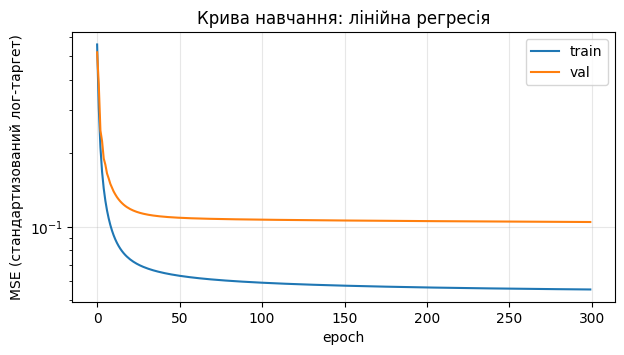

Остання епоха: train=0.0553  val=0.1046


In [39]:
h = VARIANTS["linear"]["hist"]
plt.figure(figsize=(7, 3.5))
plt.plot(h["train"], label="train"); plt.plot(h["val"], label="val")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (стандартизований лог-таргет)")
plt.title("Крива навчання: лінійна регресія"); plt.legend(); plt.grid(alpha=0.3); plt.show()
print(f"Остання епоха: train={h['train'][-1]:.4f}  val={h['val'][-1]:.4f}")

**Що видно.** Обидві криві спадають і виходять на плато: train loss 0.0553, val loss 0.1046. Перенавчання нема (val не росте), недонавчання теж не видно, бо криві вже майже плоскі. Val loss приблизно вдвічі вищий за train, що нормально для даних, яких модель не бачила. Тобто лінійна модель стабільна й добре налаштована, і з неї виходить сильний baseline для нейромереж.

#### 2.2.6. Метрики на test: baseline проти лінійної регресії

Baseline — завжди прогнозувати середню ціну train (так само, як у демо).

In [40]:
baseline_pred = np.full(len(y_test_usd), y_train_usd.mean())
BASELINE = calc_metrics(y_test_usd, baseline_pred)

def show_metrics(name, m):
    print(f"{name:22s} MSE={m['MSE']:,.0f}  RMSE={m['RMSE']:,.0f}  MAE={m['MAE']:,.0f}  R2={m['R2']:.4f}")

print(f"Середня ціна train, яку прогнозує baseline: {y_train_usd.mean():,.0f} $")
show_metrics("Baseline (середнє)", BASELINE)
show_metrics("Лінійна регресія", VARIANTS["linear"]["test"])

Середня ціна train, яку прогнозує baseline: 179,939 $
Baseline (середнє)     MSE=4,942,413,543  RMSE=70,302  MAE=54,319  R2=-0.0106
Лінійна регресія       MSE=350,433,728  RMSE=18,720  MAE=13,024  R2=0.9283


**Результат.** Baseline: RMSE 70 302 $, MAE 54 319 $, R² = −0.0106 (середнє не вгадує нічого, R² трохи нижче нуля). Лінійна регресія: RMSE 18 720 $, MAE 13 024 $, R² = 0.9283. Тобто типова помилка впала приблизно з 70 тис. до 18.7 тис. доларів при середній ціні ≈ 180 тис. (≈ 10%), а модель пояснює ~93% розкиду цін. Цей показник і буде «планкою» для нейромереж.

#### 2.2.7. Інтерпретація ваг

Ознаки стандартизовані, тож модуль ваги показує вплив на (стандартизований лог-)прогноз у порівнянних одиницях.

In [41]:
lin_w = VARIANTS["linear"]["model"].weight.detach().cpu().numpy().flatten()
w_df = pd.DataFrame({"feature": FEATURE_COLS, "weight": lin_w})
w_df["rank_by_abs"] = w_df["weight"].abs().rank(ascending=False).astype(int)
w_sorted = w_df.sort_values("rank_by_abs")
print("Топ-15 ознак за |вагою|:")
print(w_sorted.head(15).round(3).to_string(index=False))
print("\nНові ознаки з 2.1.7 (місце серед", len(FEATURE_COLS), "):")
print(w_df[w_df["feature"].isin(["TotalSF", "TotalBath", "HouseAge", "RemodAge"])].sort_values("rank_by_abs").round(3).to_string(index=False))
print("\nНайбільш «негативні» ваги:")
print(w_sorted.sort_values("weight").head(5)[["feature", "weight"]].round(3).to_string(index=False))

Топ-15 ознак за |вагою|:
              feature  weight  rank_by_abs
            GrLivArea   0.193            1
              TotalSF   0.164            2
          OverallQual   0.164            3
          MSZoning_RL   0.140            4
             HouseAge  -0.138            5
              LotArea   0.120            6
          OverallCond   0.104            7
          MSZoning_RM   0.090            8
SaleCondition_Abnorml  -0.085            9
           GarageCars   0.077           10
          MSZoning_FV   0.074           11
  Exterior2nd_VinylSd  -0.074           12
       Functional_Typ   0.074           13
        LandSlope_Mod  -0.068           14
    GarageType_Attchd   0.063           15

Нові ознаки з 2.1.7 (місце серед 175 ):
  feature  weight  rank_by_abs
  TotalSF   0.164            2
 HouseAge  -0.138            5
TotalBath   0.063           16
 RemodAge  -0.050           26

Найбільш «негативні» ваги:
              feature  weight
             HouseAge  -0.138
Sal

**Висновки по вагах.**

- Найбільший вплив мають **площа й якість**: `GrLivArea` (0.193), `TotalSF` (0.164), `OverallQual` (0.164). Це збігається з EDA, де `OverallQual` і площі були найсильніше пов'язані з ціною. Оскільки `GrLivArea` і `TotalSF` корелюють (0.86), їхній вплив ділиться між ними, важливо їхню суму, а не кожну окремо.
- **`HouseAge` має п'яту за модулем вагу, −0.138**: старіший будинок дешевший. Ознаки, які я створив у 2.1.7, працюють: `TotalSF` друга, `HouseAge` п'ята, `TotalBath` 16-та (+0.063), `RemodAge` 26-та (−0.050).
- Серед негативних ознак є `SaleCondition_Abnorml` (−0.085): нетипові продажі (наприклад, примусові) відбуваються дешевше, це логічно.
- **One-hot ваги читаються обережно.** `MSZoning_RL` (+0.140), `MSZoning_RM`, `MSZoning_FV` стоять високо, але ці колонки взаємовиключні й порівнюються лише одна з одною (та з відсіяними рідкісними зонами), тому «RL дорожчі за все» з цього робити не можна. Для висновків я спираюсь на числові ознаки.
- Ваги не є причинно-наслідковими: при корельованих ознаках (а в мене їх чимало) вони залежать від того, які ще ознаки є в моделі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично — напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна — окремий варіант.

#### 2.3.1. Три архітектури

Беру за зразок демо: `nn.Sequential`, ReLU між шарами, оптимізатор Adam з `lr=0.01`, 200 епох, повний батч. Різні архітектури відрізняються не косметично:

| варіант | прихованих шарів | ширини | активація |
|---|---|---|---|
| `nn_v1_2layers` | 2 | 64 → 32 | ReLU (як у демо) |
| `nn_v2_deeper` | 4 | 256 → 128 → 64 → 32 | ReLU |
| `nn_v3_tanh` | 4 | 256 → 128 → 64 → 32 | Tanh (та сама форма, що в v2, щоб порівняти саме активацію) |

Файли: `nn_v1.pt`, `nn_v2.pt`, `nn_v3.pt`.

In [42]:
ARCHS = {
    "nn_v1_2layers": ("nn_v1.pt", {"type": "mlp", "hidden": [64, 32], "activation": "relu"}),
    "nn_v2_deeper":  ("nn_v2.pt", {"type": "mlp", "hidden": [256, 128, 64, 32], "activation": "relu"}),
    "nn_v3_tanh":    ("nn_v3.pt", {"type": "mlp", "hidden": [256, 128, 64, 32], "activation": "tanh"}),
}
for name, (file_name, arch) in ARCHS.items():
    run_variant(name, file_name, arch)

best_arch = min(ARCHS, key=lambda n: VARIANTS[n]["final_val"])     # вибираємо за val, не за test
best_tag = "_".join(best_arch.split("_")[:2])                       # напр. "nn_v2"
print("\nНайкраща архітектура за val loss:", best_arch)
summary_table(["linear"] + list(ARCHS), "val")

nn_v1_2layers      params= 13377 | loss train=0.0005 val=0.1841 | val R2=0.9136 | збережено models/nn_v1.pt


nn_v2_deeper       params= 88321 | loss train=0.0004 val=0.1724 | val R2=0.9208 | збережено models/nn_v2.pt


nn_v3_tanh         params= 88321 | loss train=0.0023 val=0.2438 | val R2=0.8154 | збережено models/nn_v3.pt

Найкраща архітектура за val loss: nn_v2_deeper


,параметрів,train loss,val loss,"val RMSE, $","val MAE, $",val R2
варіант,,,,,,
linear,176,0.0553,0.1046,22029.0,14794.0,0.9485
nn_v1_2layers,13377,0.0005,0.1841,28530.0,19170.0,0.9136
nn_v2_deeper,88321,0.0004,0.1724,27308.0,17398.0,0.9208
nn_v3_tanh,88321,0.0023,0.2438,41697.0,22879.0,0.8154


#### 2.3.2. Криві навчання архітектур

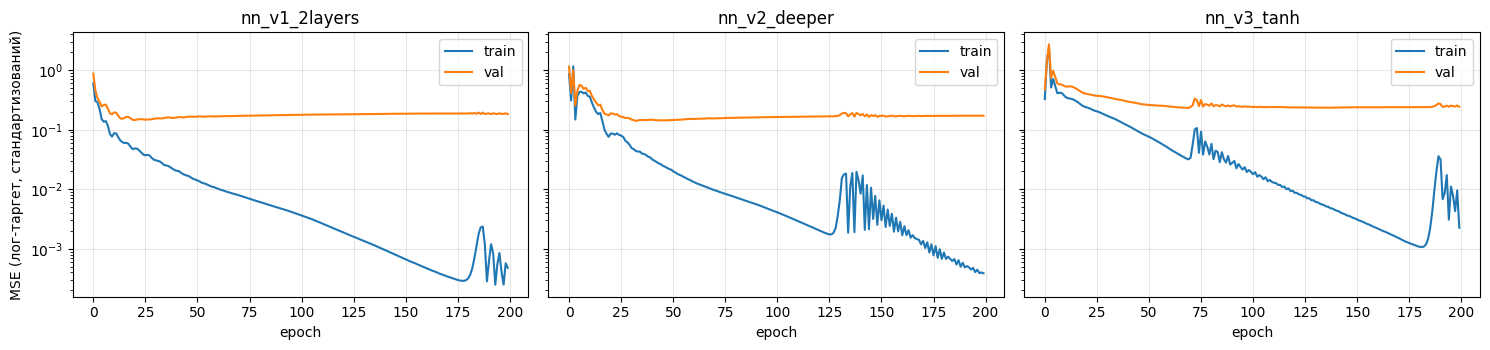

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, name in zip(axes, ARCHS):
    ax.plot(VARIANTS[name]["hist"]["train"], label="train"); ax.plot(VARIANTS[name]["hist"]["val"], label="val")
    ax.set_yscale("log"); ax.set_title(name); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("MSE (лог-таргет, стандартизований)")
plt.tight_layout(); plt.show()

**Що вийшло.**

| варіант | параметрів | train loss | val loss | val R² |
|---|---|---|---|---|
| лінійна | 176 | 0.0553 | **0.1046** | **0.9485** |
| `nn_v1_2layers` | 13 377 | 0.0005 | 0.1841 | 0.9136 |
| `nn_v2_deeper` | 88 321 | 0.0004 | 0.1724 | 0.9208 |
| `nn_v3_tanh` | 88 321 | 0.0023 | 0.2438 | 0.8154 |

- **Усі нейромережі сильно перенавчаються.** Train loss близько нуля (на 1-2 порядки нижче, ніж у лінійної моделі), а val loss у 1.6-2.3 раза вищий за лінійну. На графіках видно, що val мінімальний у перші десятки епох, а далі лише повільно повзе вгору, тоді як train продовжує падати. Причина зрозуміла: 874 навчальних рядки, 175 ознак і від 13 до 88 тисяч параметрів. Мережа просто запам'ятовує будинки.
- На train loss помітні різкі стрибки (наприклад, у `nn_v2_deeper` з ≈ 130-ї епохи). Схоже на нестабільність Adam з `lr = 0.01`, коли loss уже мізерний, а крок лишається великим.
- Глибша `nn_v2_deeper` трохи краща за `nn_v1_2layers` (val loss 0.1724 проти 0.1841), але різниця мала, і це один seed (нижче перевірю, що таке розкид).
- **Tanh (`nn_v3_tanh`) найгірша**: при тій самій формі, що й `nn_v2_deeper`, val loss 0.2438 проти 0.1724 і val R² 0.8154 проти 0.9208. На цих даних ReLU підходить значно краще.
- За val loss найкраща з нейромереж `nn_v2_deeper`, її беру для підбору гіперпараметрів. Але **лінійна регресія на val краща за всіх трьох**.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** — інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** — якщо є час і бажання поекспериментувати більше, це тільки заохочується.

#### 2.4.1. Гіперпараметри для найкращої архітектури

Беру архітектуру, яка показала найменший val loss у 2.3 (змінна `best_arch`), і за один прогін змінюю **рівно один параметр** відносно її базового налаштування (Adam, `lr=0.01`, 200 епох, повний батч, без weight decay):

| варіант | що змінено |
|---|---|
| `<base>_lr_0.001` | learning rate 0.01 → 0.001 |
| `<base>_sgd` | оптимізатор Adam → SGD (lr лишається 0.01, щоб змінилось справді тільки одне) |
| `<base>_bs32` | розмір батча: весь train → 32 |
| `<base>_wd_0.01` | weight decay 0 → 0.01 (L2-регуляризація) |
| `<base>_epochs60` | епох 200 → 60 |

Тут `<base>` — тег найкращої архітектури, `nn_v2` у моєму прогоні.

In [44]:
base_arch = ARCHS[best_arch][1]
HP_VARIANTS = [
    (f"{best_tag}_lr_0.001",  dict(lr=0.001)),
    (f"{best_tag}_sgd",       dict(optimizer="sgd")),
    (f"{best_tag}_bs32",      dict(batch_size=32)),
    (f"{best_tag}_wd_0.01",   dict(weight_decay=0.01)),
    (f"{best_tag}_epochs60",  dict(epochs=60)),
]
for name, overrides in HP_VARIANTS:
    run_variant(name, f"{name}.pt", base_arch, **overrides)

hp_names = [n for n, _ in HP_VARIANTS]
print(f"\nБаза для порівняння: {best_arch} (Adam, lr=0.01, 200 епох)")
summary_table([best_arch] + hp_names, "val")

nn_v2_lr_0.001     params= 88321 | loss train=0.0002 val=0.1487 | val R2=0.9389 | збережено models/nn_v2_lr_0.001.pt


nn_v2_sgd          params= 88321 | loss train=0.4602 val=0.6177 | val R2=0.4575 | збережено models/nn_v2_sgd.pt


nn_v2_bs32         params= 88321 | loss train=0.0087 val=0.1565 | val R2=0.9408 | збережено models/nn_v2_bs32.pt


nn_v2_wd_0.01      params= 88321 | loss train=0.0127 val=0.1348 | val R2=0.9419 | збережено models/nn_v2_wd_0.01.pt


nn_v2_epochs60     params= 88321 | loss train=0.0137 val=0.1517 | val R2=0.9416 | збережено models/nn_v2_epochs60.pt

База для порівняння: nn_v2_deeper (Adam, lr=0.01, 200 епох)


,параметрів,train loss,val loss,"val RMSE, $","val MAE, $",val R2
варіант,,,,,,
nn_v2_deeper,88321,0.0004,0.1724,27308.0,17398.0,0.9208
nn_v2_lr_0.001,88321,0.0002,0.1487,23988.0,16439.0,0.9389
nn_v2_sgd,88321,0.4602,0.6177,71479.0,42404.0,0.4575
nn_v2_bs32,88321,0.0087,0.1565,23607.0,15918.0,0.9408
nn_v2_wd_0.01,88321,0.0127,0.1348,23400.0,16404.0,0.9419
nn_v2_epochs60,88321,0.0137,0.1517,23443.0,15978.0,0.9416


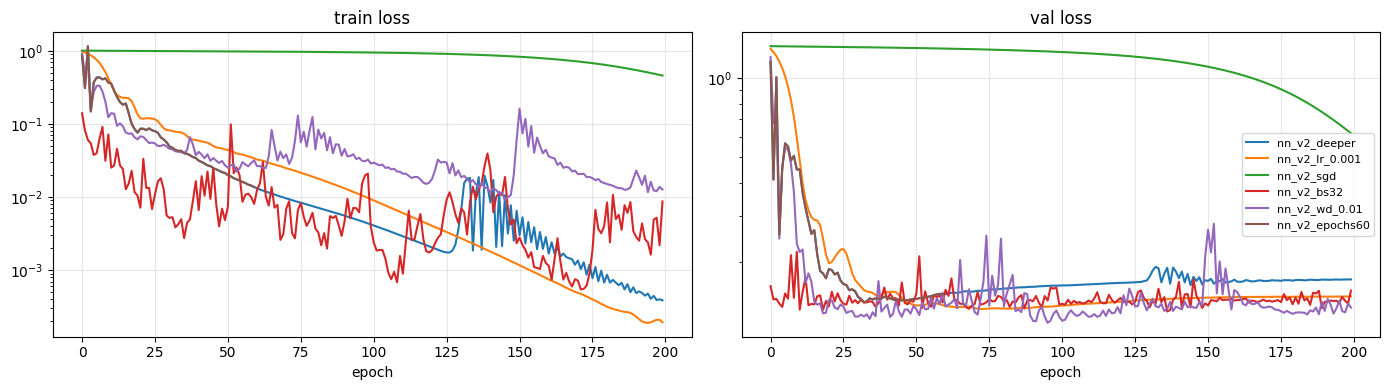

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in [best_arch] + hp_names:
    axes[0].plot(VARIANTS[name]["hist"]["train"], label=name)
    axes[1].plot(VARIANTS[name]["hist"]["val"], label=name)
for ax, t in zip(axes, ["train loss", "val loss"]):
    ax.set_yscale("log"); ax.set_title(t); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Результати (val), база `nn_v2_deeper`:**

| що змінено | val loss | val R² |
|---|---|---|
| база (Adam, lr 0.01, 200 епох) | 0.1724 | 0.9208 |
| `lr = 0.001` | 0.1487 | 0.9389 |
| оптимізатор SGD (lr 0.01) | 0.6177 | 0.4575 |
| `batch_size = 32` | 0.1565 | 0.9408 |
| `weight_decay = 0.01` | **0.1348** | **0.9419** |
| `epochs = 60` | 0.1517 | 0.9416 |

**Що з цього випливає.**

- Чотири зміни з п'яти **поліпшили val**, і всі вони боряться з перенавчанням: менший `lr`, шум міні-батчів, L2-регуляризація, коротше навчання. Усі дають val R² ≈ 0.94 проти 0.92 у бази. Тобто проблема моделі не в нестачі потужності, а в перенавчанні.
- **`weight_decay = 0.01` дав найменший val loss (0.1348)** і суттєво змінив картину на train: train loss піднявся з 0.0004 до 0.0127, тобто мережа перестала запам'ятовувати. Це показник того, що регуляризація працює.
- **SGD з тим самим `lr = 0.01` катастрофічно гірший**: за 200 епох train loss лише 0.46 (у Adam 0.0004), мережа недонавчена. SGD без адаптації кроку потребує більшого `lr` або більше епох. Я цього не підбирав, бо правило було змінювати лише один параметр. Це результат саме «SGD за незмінного `lr`», а не вирок SGD загалом.
- Із `epochs = 60` результат такий самий добрий, як і з іншими змінами: ранній мінімум val, який ми бачили на кривих, підтверджується.
- Цікаво, що жоден варіант не дотягнув до лінійної моделі на val (val loss 0.1046, val R² 0.9485).

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) — з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

#### 2.5.1. TensorBoard

Усі 9 варіантів залоговані в підпапки `runs/` (кожен — окремий run). Нижче запускається TensorBoard прямо в ноутбуці (у Colab і локальному Jupyter), а під ним — ті самі криві, прочитані з event-файлів і накладені одна на одну matplotlib-ом, на випадок, якщо TensorBoard у вашому середовищі не відкриється.

In [46]:
try:
    _ip = get_ipython()
    _ip.run_line_magic("load_ext", "tensorboard")
    _ip.run_line_magic("tensorboard", f"--logdir {RUNS_DIR}")
except Exception as e:
    print("TensorBoard у цьому середовищі не запустився:", type(e).__name__, "-> запустіть у терміналі: tensorboard --logdir runs")

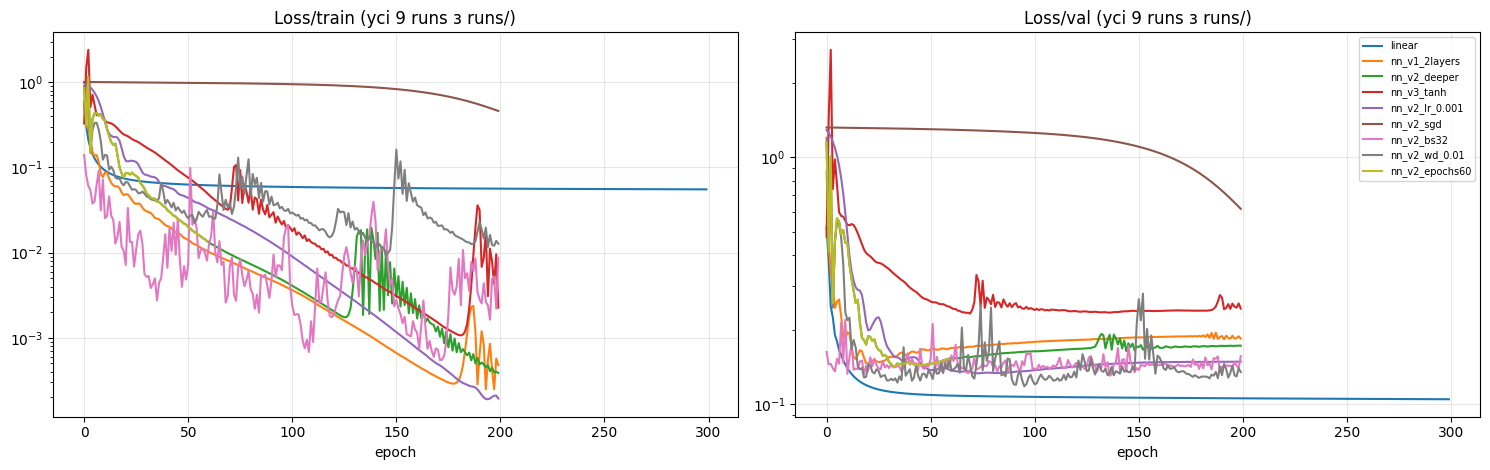

Папки в runs/: ['linear', 'nn_v1_2layers', 'nn_v2_bs32', 'nn_v2_deeper', 'nn_v2_epochs60', 'nn_v2_lr_0.001', 'nn_v2_sgd', 'nn_v2_wd_0.01', 'nn_v3_tanh']


In [47]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for run in VARIANTS:                       # порядок запуску
    ea = EventAccumulator(os.path.join(RUNS_DIR, run)); ea.Reload()
    for ax, tag in zip(axes, ["Loss/train", "Loss/val"]):
        ev = ea.Scalars(tag)
        ax.plot([e.step for e in ev], [e.value for e in ev], label=run)
for ax, t in zip(axes, ["Loss/train", "Loss/val"]):
    ax.set_yscale("log"); ax.set_title(t + " (усі 9 runs з runs/)"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
print("Папки в runs/:", sorted(os.listdir(RUNS_DIR)))

#### 2.5.2. Зведена таблиця результатів на test

Метрики на test у доларах (MSE — в доларах², RMSE і MAE — у доларах, R² — безрозмірний). Таблиця зберігається в `results.csv`. Baseline показую окремо, у файл він не йде (там лише варіанти моделей, у яких є свій `.pt`).

In [48]:
res_rows = [{"model": n, "MSE": v["test"]["MSE"], "RMSE": v["test"]["RMSE"], "MAE": v["test"]["MAE"], "R2": v["test"]["R2"]}
            for n, v in VARIANTS.items()]
results = pd.DataFrame(res_rows).sort_values("RMSE").reset_index(drop=True)
results.to_csv(RESULTS_CSV, index=False)
print("Збережено:", RESULTS_CSV, "| рядків:", len(results))

show = results.copy()
show["MSE"] = show["MSE"].map("{:,.0f}".format)
show["RMSE"] = show["RMSE"].map("{:,.0f}".format)
show["MAE"] = show["MAE"].map("{:,.0f}".format)
show["R2"] = show["R2"].round(4)
print(f"\nBaseline (середнє train): RMSE={BASELINE['RMSE']:,.0f}  MAE={BASELINE['MAE']:,.0f}  R2={BASELINE['R2']:.4f}\n")
show

Збережено: /tmp/build/final/lab2/results.csv | рядків: 9

Baseline (середнє train): RMSE=70,302  MAE=54,319  R2=-0.0106



,model,MSE,RMSE,MAE,R2
0,linear,"350,433,728","18,720","13,024",0.9283
1,nn_v2_epochs60,"379,039,648","19,469","13,535",0.9225
2,nn_v2_bs32,"384,613,824","19,612","13,477",0.9214
3,nn_v2_wd_0.01,"424,738,976","20,609","13,683",0.9132
4,nn_v2_lr_0.001,"428,101,664","20,691","14,360",0.9125
5,nn_v2_deeper,"465,709,600","21,580","14,155",0.9048
6,nn_v1_2layers,"538,313,920","23,202","15,773",0.8899
7,nn_v3_tanh,"835,900,096","28,912","17,621",0.8291
8,nn_v2_sgd,"2,099,384,448","45,819","32,382",0.5707


In [49]:
# Те саме, але з val-метриками, кількістю параметрів і налаштуваннями - щоб було видно, що саме змінювалось
detail = []
for n, v in VARIANTS.items():
    hp = v["hp"]
    detail.append({"model": n, "файл": v["file"], "параметрів": v["params"], "optimizer": hp["optimizer"], "lr": hp["lr"],
                   "epochs": hp["epochs"], "batch": hp["batch_size"] or "full", "wd": hp["weight_decay"],
                   "val R2": round(v["val"]["R2"], 4), "test R2": round(v["test"]["R2"], 4),
                   "test RMSE, $": round(v["test"]["RMSE"])})
pd.DataFrame(detail).set_index("model").loc[results["model"]]

,файл,параметрів,optimizer,lr,epochs,batch,wd,val R2,test R2,"test RMSE, $"
model,,,,,,,,,,
linear,linear.pt,176,sgd,0.050,300,full,0.00,0.9485,0.9283,18720
nn_v2_epochs60,nn_v2_epochs60.pt,88321,adam,0.010,60,full,0.00,0.9416,0.9225,19469
nn_v2_bs32,nn_v2_bs32.pt,88321,adam,0.010,200,32,0.00,0.9408,0.9214,19612
nn_v2_wd_0.01,nn_v2_wd_0.01.pt,88321,adam,0.010,200,full,0.01,0.9419,0.9132,20609
nn_v2_lr_0.001,nn_v2_lr_0.001.pt,88321,adam,0.001,200,full,0.00,0.9389,0.9125,20691
nn_v2_deeper,nn_v2.pt,88321,adam,0.010,200,full,0.00,0.9208,0.9048,21580
nn_v1_2layers,nn_v1.pt,13377,adam,0.010,200,full,0.00,0.9136,0.8899,23202
nn_v3_tanh,nn_v3.pt,88321,adam,0.010,200,full,0.00,0.8154,0.8291,28912
nn_v2_sgd,nn_v2_sgd.pt,88321,sgd,0.010,200,full,0.00,0.4575,0.5707,45819


#### 2.5.3. Чи можна довіряти різниці між варіантами: кілька seed-ів

Різниця між нейромережами в таблиці — це одна гра випадкових ваг. Щоб не робити висновків із шуму, беру нейромережу з найменшим val loss (вибір за val, не за test) і для неї та для лінійної регресії повторюю тренування з 5 різними seed (змінюються ініціалізація ваг і порядок батчів, налаштування ті самі). Ці прогони не йдуть ні в `runs/`, ні в `models/`, ні в `results.csv`.

In [50]:
nn_names = [n for n in VARIANTS if n != "linear"]
best_nn_val = min(nn_names, key=lambda n: VARIANTS[n]["final_val"])
print("Нейромережа з найменшим val loss:", best_nn_val)

def multi_seed(name, seeds=(0, 1, 2, 3, 4)):
    v = VARIANTS[name]
    out = []
    for s in seeds:
        set_seed(s)
        m = build_model(v["arch"], X_train.shape[1]).to(device)
        train_model(m, "tmp", seed=s, log=False, **v["hp"])
        out.append(metrics_usd(m, x_test_t, y_test_usd))
    return pd.DataFrame(out)

ms = {n: multi_seed(n) for n in ["linear", best_nn_val]}
rows = [{"модель": n, "test R2 (середнє)": d["R2"].mean(), "± std": d["R2"].std(),
         "test RMSE, $ (середнє)": d["RMSE"].mean(), "± std, $": d["RMSE"].std()} for n, d in ms.items()]
pd.DataFrame(rows).set_index("модель").round({"test R2 (середнє)": 4, "± std": 4, "test RMSE, $ (середнє)": 0, "± std, $": 0})

Нейромережа з найменшим val loss: nn_v2_wd_0.01


,test R2 (середнє),± std,"test RMSE, $ (середнє)","± std, $"
модель,,,,
linear,0.9274,0.0007,18842.0,88.0
nn_v2_wd_0.01,0.9058,0.0108,21442.0,1194.0


#### 2.5.4. Перевірка збережених моделей

Щоб упевнитись, що `.pt` файли справді робочі, завантажую кожен із диска, відновлюю модель з архітектури, що лежить у файлі, і проганяю **сирі** test-дані через весь препроцесинг. Метрики мають збігтися з `results.csv`.

In [51]:
def load_variant(file_name):
    ckpt = torch.load(os.path.join(MODELS_DIR, file_name), map_location=device)
    model = build_model(ckpt["arch"], len(ckpt["feature_names"])).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model, ckpt

x_test_from_raw = torch.tensor(preprocess_raw(raw_test), dtype=torch.float32).to(device)
rows, all_ok = [], True
for n, v in VARIANTS.items():
    model, ckpt = load_variant(v["file"])
    m = calc_metrics(y_test_usd, predict_usd(model, x_test_from_raw))
    ok = abs(m["R2"] - v["test"]["R2"]) < 1e-5
    all_ok &= ok
    rows.append({"model": n, "файл": v["file"], "R2 з файлу": round(m["R2"], 4), "R2 в results.csv": round(v["test"]["R2"], 4), "збіг": ok})
print("Усі моделі відтворюються з диска:", all_ok)
pd.DataFrame(rows).set_index("model")

Усі моделі відтворюються з диска: True


,файл,R2 з файлу,R2 в results.csv,збіг
model,,,,
linear,linear.pt,0.9283,0.9283,True
nn_v1_2layers,nn_v1.pt,0.8899,0.8899,True
nn_v2_deeper,nn_v2.pt,0.9048,0.9048,True
nn_v3_tanh,nn_v3.pt,0.8291,0.8291,True
nn_v2_lr_0.001,nn_v2_lr_0.001.pt,0.9125,0.9125,True
nn_v2_sgd,nn_v2_sgd.pt,0.5707,0.5707,True
nn_v2_bs32,nn_v2_bs32.pt,0.9214,0.9214,True
nn_v2_wd_0.01,nn_v2_wd_0.01.pt,0.9132,0.9132,True
nn_v2_epochs60,nn_v2_epochs60.pt,0.9225,0.9225,True


#### 2.5.5. Висновки

Усі метрики нижче на test, у доларах. Вибір архітектури і гіперпараметрів я робив за val, на test дивлюсь тільки тут.

**1. Яка модель перемогла і наскільки суттєво?**

Перемогла **лінійна регресія**: RMSE 18 720 $, MAE 13 024 $, R² = 0.9283. Найкраща нейромережа за test (`nn_v2_epochs60`) має RMSE 19 469 $ і R² = 0.9225, тобто гірша приблизно на 4%. Але вона найкраща лише за test; нейромережа, яку я вибрав за val (`nn_v2_wd_0.01`), на test має RMSE 20 609 $ (R² = 0.9132), це на 10% гірше за лінійну. Окрема перевірка на 5 seed (2.5.3) показує, що виграш лінійної моделі не випадковий: R² лінійної 0.9274 ± 0.0007, а нейромережі 0.9058 ± 0.0108, у середньому RMSE 18 842 $ проти 21 442 $, тобто лінійна точніша приблизно на 14%. Також помітно, що одиничний прогін нейромережі (R² 0.9132) оптимістичніший за середнє по seed-ах (0.9058), тому різницю між нейромережами на одному seed не варто сприймати серйозно. Для порівняння, baseline (середня ціна) дає RMSE 70 302 $ і R² = −0.0106, тож усі «нормальні» моделі дуже далеко від нього.

**2. Чи виправдала себе нейромережа порівняно з лінійною регресією на моєму датасеті?**

**Ні.** Причини, які я бачу:

- **Мало даних, багато параметрів.** 874 навчальних рядки проти 175 ознак і 13-88 тисяч параметрів у нейромережах. Базові мережі майже ідеально запам'ятовують train (loss ≈ 10⁻⁴), а їхній val loss у 1.6-2.3 раза вищий за лінійну модель.
- **Задача майже лінійна.** Ціна Ames після логарифма добре пояснюється сумою внесків (площа, якість, вік, район), і лінійна модель уже дає R² ≈ 0.93. Нелінійного сигналу, який нейромережа могла б додатково знайти, лишається мало.
- У демо з California Housing усе навпаки: там 12 тисяч рядків і 7 ознак, лінійна модель дає R² 0.60, а нейромережа 0.73 (див. 0.1, питання 4). Там складність виправдана, бо лінійна модель явно «не дотягує». Тут «не дотягувати» нема чому.

**3. Що з моїх змін дало найбільший ефект?**

- **Найбільший вплив мали зміни, які погіршили результат.** SGD з незмінним `lr = 0.01` знизив test R² з 0.9048 до 0.5707 (мережа недонавчена, див. 2.4.1), а заміна ReLU на Tanh при тій самій формі мережі знизила його до 0.8291.
- **Серед змін, що поліпшили,** найкращі `epochs = 60` (R² 0.9225, +0.018 до бази 0.9048) і `batch_size = 32` (0.9214, +0.017), далі `weight_decay = 0.01` (+0.008) і `lr = 0.001` (+0.008). Архітектура: перехід від 2 до 4 шарів (`nn_v1` → `nn_v2`) дав приблизно +0.015.
- Ці поліпшення за розміром (≈ 0.01-0.02) співмірні з розкидом нейромережі між seed-ами (±0.011), тому серед `epochs60`, `bs32`, `wd` і `lr` я переможця не оголошую. Зате на val усі чотири змінили картину однаково (R² з 0.921 до ≈ 0.94), і всі вони борються з перенавчанням. Тож головний висновок: для моєї нейромережі найважливіше **не глибина, а стримування перенавчання** (регуляризація, менший крок, раніше зупинити тренування).

**Що я б спробував далі** (це ідеї, я їх не перевіряв): dropout, зупинка за val (early stopping), комбінація кількох змін відразу і усереднення кількох мереж. Але навіть тоді виграти в лінійної моделі з R² 0.93 на 874 рядках буде непросто.

---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

Побудуйте аппку для своїх моделей

#### 3.1. Що робить застосунок

Застосунок підвантажує **всі 9 натренованих варіантів із `models/*.pt`** (тобто перевіряє заодно, що файли робочі) і порівнює їхні прогнози ціни наживо. Є дві вкладки:

1. **«Свій будинок»** — задаєш 13 основних характеристик (якість, площі, рік, район, ванни, гараж, кухня), решту ознак застосунок підставляє типовими значеннями з train (медіана для чисел, мода для категорій). Це обмеження: на ціну впливають і ті ознаки, яких тут нема, тому прогноз приблизний.
2. **«Будинок з test»** — вибираєш номер реального будинку з тестової вибірки, а застосунок показує справжню ціну і прогнози всіх моделей.

Введені значення проходять через **ту саму функцію `preprocess_raw`**, що й дані при навчанні (заповнення пропусків, нові ознаки, log1p, кодування, стандартизація), а прогноз перетворюється назад у долари.

In [52]:
import gradio as gr

# --- 1. завантажуємо всі варіанти з models/*.pt ---
APP_MODELS = {name: load_variant(v["file"])[0] for name, v in VARIANTS.items()}

# --- 2. «типовий» будинок: медіана/мода по сирому train ---
def make_template(df):
    t = {}
    for c in df.columns:
        if c == TARGET:
            continue
        t[c] = df[c].fillna("None").mode()[0] if c in CAT_COLS else float(df[c].median())
    return t

TEMPLATE = make_template(raw_train)

def predict_all(df_row):
    x = torch.tensor(preprocess_raw(df_row), dtype=torch.float32).to(device)
    out = {}
    for name, model in APP_MODELS.items():
        model.eval()
        with torch.no_grad():
            out[name] = float(decode_target(model(x).cpu().numpy().ravel())[0])
    return out

def q(col, lo=0.01, hi=0.99):
    return int(raw_train[col].quantile(lo)), int(raw_train[col].quantile(hi))

def build_row(overall_qual, neighborhood, floor1, floor2, bsmt, lot_area, year_built, year_remod,
              full_bath, half_bath, bedrooms, garage_cars, kitchen_qual):
    row = dict(TEMPLATE)
    year_remod = max(year_remod, year_built)                  # ремонт не може бути раніше побудови
    row.update({"OverallQual": overall_qual, "Neighborhood": neighborhood,
                "1stFlrSF": floor1, "2ndFlrSF": floor2, "GrLivArea": floor1 + floor2,
                "TotalBsmtSF": bsmt, "LotArea": lot_area, "YearBuilt": year_built, "YearRemodAdd": year_remod,
                "FullBath": full_bath, "HalfBath": half_bath, "BedroomAbvGr": bedrooms,
                "GarageCars": garage_cars, "KitchenQual": kitchen_qual})
    if garage_cars == 0:                                       # гаража нема -> узгоджуємо пов'язані поля
        row.update({"GarageArea": 0, "GarageType": "None", "GarageFinish": "None",
                    "GarageQual": "None", "GarageCond": "None"})
    if bsmt == 0:                                              # підвалу нема
        row.update({"BsmtQual": "None", "BsmtCond": "None", "BsmtExposure": "None",
                    "BsmtFinType1": "None", "BsmtFinType2": "None", "BsmtFinSF1": 0, "BsmtFinSF2": 0, "BsmtUnfSF": 0,
                    "BsmtFullBath": 0, "BsmtHalfBath": 0})
    return pd.DataFrame([row])

def bar_figure(preds, true_price=None):
    names = list(preds)
    vals = [preds[n] for n in names]
    fig, ax = plt.subplots(figsize=(7, 4.2))
    colors = ["#C44E52" if n == "linear" else "#4C72B0" for n in names]
    ax.barh(names[::-1], vals[::-1], color=colors[::-1])
    if true_price is not None:
        ax.axvline(true_price, color="green", ls="--", label=f"справжня ціна: {true_price:,.0f} $")
        ax.legend(loc="lower right", fontsize=8)
    ax.set_xlabel("Прогноз SalePrice, $"); ax.set_title("Порівняння всіх варіантів моделі")
    ax.grid(alpha=0.3, axis="x"); plt.tight_layout()
    plt.close(fig)
    return fig

def pred_table(preds, true_price=None):
    df = pd.DataFrame({"модель": list(preds), "прогноз, $": [round(v) for v in preds.values()]})
    if true_price is not None:
        df["похибка, $"] = (df["прогноз, $"] - round(true_price)).astype(int)
    return df

def run_custom(selected, *vals):
    preds = predict_all(build_row(*vals))
    return round(preds[selected]), bar_figure(preds), pred_table(preds)

def run_test_house(selected, idx):
    idx = int(idx)
    row = raw_test.iloc[[idx]]
    true_price = float(row[TARGET].iloc[0])
    preds = predict_all(row.drop(columns=[TARGET]))
    r = row.iloc[0]
    info = (f"Будинок №{idx} з test: район **{r['Neighborhood']}**, якість {r['OverallQual']}/10, "
            f"житлова площа {int(r['GrLivArea'])} кв. фт, збудований {int(r['YearBuilt'])}. "
            f"Справжня ціна: **{true_price:,.0f} $**.")
    return info, round(preds[selected]), bar_figure(preds, true_price), pred_table(preds, true_price)

model_names = list(APP_MODELS)

with gr.Blocks(title="Ames House Prices: порівняння моделей") as demo:
    gr.Markdown("## Прогноз ціни будинку (Ames, Айова): лінійна регресія проти нейромереж\n"
                "Усі 9 варіантів із лабораторної, завантажені з `models/*.pt`.")
    with gr.Tab("Свій будинок"):
        with gr.Row():
            with gr.Column():
                i_qual = gr.Slider(1, 10, value=int(TEMPLATE["OverallQual"]), step=1, label="OverallQual (загальна якість, 1-10)")
                i_nb = gr.Dropdown(sorted(raw_train["Neighborhood"].unique()), value=TEMPLATE["Neighborhood"], label="Neighborhood (район)")
                lo, hi = q("1stFlrSF"); i_f1 = gr.Slider(lo, hi, value=int(TEMPLATE["1stFlrSF"]), step=10, label="1stFlrSF (1-й поверх, кв. фт)")
                i_f2 = gr.Slider(0, q("2ndFlrSF", 0, 0.99)[1], value=0, step=10, label="2ndFlrSF (2-й поверх, кв. фт)")
                i_bs = gr.Slider(0, q("TotalBsmtSF", 0, 0.99)[1], value=int(TEMPLATE["TotalBsmtSF"]), step=10, label="TotalBsmtSF (підвал, кв. фт; 0 = нема)")
                lo, hi = q("LotArea"); i_lot = gr.Slider(lo, hi, value=int(TEMPLATE["LotArea"]), step=100, label="LotArea (ділянка, кв. фт)")
                i_yb = gr.Slider(1880, 2010, value=int(raw_train["YearBuilt"].median()), step=1, label="YearBuilt (рік побудови)")
                i_yr = gr.Slider(1950, 2010, value=int(raw_train["YearRemodAdd"].median()), step=1, label="YearRemodAdd (рік ремонту)")
                i_fb = gr.Slider(0, 3, value=int(TEMPLATE["FullBath"]), step=1, label="FullBath (повні ванни)")
                i_hb = gr.Slider(0, 2, value=int(TEMPLATE["HalfBath"]), step=1, label="HalfBath (напівванни)")
                i_br = gr.Slider(0, 6, value=int(TEMPLATE["BedroomAbvGr"]), step=1, label="BedroomAbvGr (спальні)")
                i_gc = gr.Slider(0, 4, value=int(TEMPLATE["GarageCars"]), step=1, label="GarageCars (місць у гаражі)")
                i_kq = gr.Dropdown(["Ex", "Gd", "TA", "Fa"], value=TEMPLATE["KitchenQual"], label="KitchenQual (кухня)")
                sel1 = gr.Dropdown(model_names, value=model_names[0], label="Основна модель")
                btn1 = gr.Button("Порахувати прогноз", variant="primary")
            with gr.Column():
                out_num1 = gr.Number(label="Прогноз обраної моделі, $")
                out_plot1 = gr.Plot(label="Порівняння всіх варіантів")
                out_tab1 = gr.Dataframe(label="Усі прогнози")
        btn1.click(run_custom, inputs=[sel1, i_qual, i_nb, i_f1, i_f2, i_bs, i_lot, i_yb, i_yr, i_fb, i_hb, i_br, i_gc, i_kq],
                   outputs=[out_num1, out_plot1, out_tab1])
    with gr.Tab("Будинок з test"):
        with gr.Row():
            with gr.Column():
                i_idx = gr.Slider(0, len(raw_test) - 1, value=0, step=1, label="Номер будинку в test")
                sel2 = gr.Dropdown(model_names, value=model_names[0], label="Основна модель")
                btn2 = gr.Button("Показати", variant="primary")
                out_info2 = gr.Markdown()
            with gr.Column():
                out_num2 = gr.Number(label="Прогноз обраної моделі, $")
                out_plot2 = gr.Plot(label="Порівняння з справжньою ціною")
                out_tab2 = gr.Dataframe(label="Усі прогнози")
        btn2.click(run_test_house, inputs=[sel2, i_idx], outputs=[out_info2, out_num2, out_plot2, out_tab2])

# швидка перевірка логіки без UI: «типовий» будинок і ті самі функції, які викликають кнопки
_defaults = [TEMPLATE["OverallQual"], TEMPLATE["Neighborhood"], TEMPLATE["1stFlrSF"], 0, TEMPLATE["TotalBsmtSF"],
             TEMPLATE["LotArea"], int(raw_train["YearBuilt"].median()), int(raw_train["YearRemodAdd"].median()),
             TEMPLATE["FullBath"], TEMPLATE["HalfBath"], TEMPLATE["BedroomAbvGr"], TEMPLATE["GarageCars"], TEMPLATE["KitchenQual"]]
_p = predict_all(build_row(*_defaults))
print("Прогноз для «типового» будинку:", {k: round(v) for k, v in _p.items()})
_n1, _f1, _t1 = run_custom(model_names[0], *_defaults)
_info, _n2, _f2, _t2 = run_test_house(model_names[0], 0)
print(f"Колбеки кнопок працюють: run_custom -> {_n1:,} $; run_test_house(0) -> {_n2:,} $ при справжній ціні {float(raw_test.iloc[0][TARGET]):,.0f} $")

/usr/local/lib/python3.12/dist-packages/gradio/analytics.py:99: UserWarning: unable to parse version details from package URL.
  warnings.warn("unable to parse version details from package URL.")


Прогноз для «типового» будинку: {'linear': 148409, 'nn_v1_2layers': 146530, 'nn_v2_deeper': 148396, 'nn_v3_tanh': 126012, 'nn_v2_lr_0.001': 146099, 'nn_v2_sgd': 165594, 'nn_v2_bs32': 151785, 'nn_v2_wd_0.01': 157420, 'nn_v2_epochs60': 145128}
Колбеки кнопок працюють: run_custom -> 148,409 $; run_test_house(0) -> 155,627 $ при справжній ціні 180,500 $


In [53]:
# запуск (prevent_thread_lock=True, щоб клітинка завершувалась і Run All доходив до кінця; застосунок живе, поки живе ядро)
try:
    app.close()                      # якщо запускали раніше - закриваємо стару копію
except NameError:
    pass
app = demo
app.launch(share=IN_COLAB, inline=True, prevent_thread_lock=True, quiet=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


#### 3.2. Що цікавого й які обмеження

- **Моделі розходяться на одному вході.** Для «типового» будинку (медіанні значення всіх ознак) лінійна модель і `nn_v2_deeper` дають майже однаково (≈ 148 тис. $), більшість інших нейромереж 145-157 тис. $, а `nn_v3_tanh` лише 126 тис. $, тоді як недонавчена `nn_v2_sgd` 166 тис. $. Це добре видно на стовпчиковому графіку: гірші за метриками моделі помітно відхиляються від решти.
- **Вкладка «Будинок з test»** показує справжню ціну пунктиром, тому на ній видно, у яких будинках промахується кожна модель, а не лише середню метрику.
- **Обмеження:** користувач задає лише 13 характеристик, решта підставляється типовими значеннями з train, тож прогноз приблизний. Площі й розмір ділянки в повзунках обмежені 1-99-м перцентилем train, щоб не просити модель про екстраполяцію. Інтервалів невпевненості нема, є лише точкова оцінка. Дані з Еймса за 2006-2010 роки, тому ціни відповідають тому періоду й тому місту.
- **Труднощі:** потрібно було гарантувати, що застосунок готує вхід так само, як тренування. Для цього весь препроцесинг зібраний в одну функцію `preprocess_raw`, і ще в 2.2.1 я перевіряю, що вона відтворює `X_val` і `X_test` один-в-один.

---
### Як здавати лабу

У форму (https://forms.gle/8Dbc9zB8L5tsNuNEA) здати посилання на **публічний** репозиторій, який містить:

1. **Цей ноутбук з усіма виконаними пунктами**. Має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Файли всіх натренованих варіантів моделі** (2.2-2.4) — лінійна регресія + всі варіанти нейромережі, кожен окремим `.pt` файлом.
3. **Логи TensorBoard** — папка `runs/` з усіма прогонами, щоб можна було відкрити криві навчання, не перезапускаючи ноутбук.
4. **Таблицю результатів** — `results.csv` з порівнянням усіх варіантів (модель, MSE, RMSE, MAE, R² на test).
5. **Відео демонстрації TensorBoard & Gradio-застосунку** замість скріншотів цього разу: 60-90 секунд. На відео показуєте тренування і роботу моделей і коротко розповідаєте про цікаве (можливості, обмеження, труднощі тренування).
6. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
/lab2/nn_task.ipynb
/lab2/models/linear.pt
/lab2/models/nn_v1.pt
/lab2/models/nn_v2.pt
/lab2/models/...        (усі інші варіанти з 2.3-2.4)
/lab2/runs/*
/lab2/results.csv
/lab2/demo.mp4
```

#### Перевірка структури перед здачею

Клітинка нижче перевіряє, що поряд із ноутбуком лежить усе, що вимагає умова. **`demo.mp4`** (відео 60-90 секунд із TensorBoard і Gradio) ноутбук створити не може — його треба записати самому і покласти в `lab2/`.

In [54]:
required = ["nn_task.ipynb", "models/linear.pt", "models/nn_v1.pt", "models/nn_v2.pt", "runs", "results.csv", "demo.mp4"]
extra_models = sorted(set(f"models/{v['file']}" for v in VARIANTS.values()) - {"models/linear.pt", "models/nn_v1.pt", "models/nn_v2.pt"})
print("Папка з артефактами:", ARTIFACT_DIR, "\n")
for rel in required + extra_models:
    path = os.path.join(ARTIFACT_DIR, rel)
    exists = os.path.exists(path)
    if rel == "runs" and exists:
        note = f"{len(os.listdir(path))} прогонів: " + ", ".join(sorted(os.listdir(path)))
    else:
        note = ""
    status = "OK     " if exists else ("ЗАПИСАТИ" if rel == "demo.mp4" else "НЕМАЄ  ")
    print(f"[{status}] {rel} {note}")

Папка з артефактами: /tmp/build/final/lab2 

[OK     ] nn_task.ipynb 
[OK     ] models/linear.pt 
[OK     ] models/nn_v1.pt 
[OK     ] models/nn_v2.pt 
[OK     ] runs 9 прогонів: linear, nn_v1_2layers, nn_v2_bs32, nn_v2_deeper, nn_v2_epochs60, nn_v2_lr_0.001, nn_v2_sgd, nn_v2_wd_0.01, nn_v3_tanh
[OK     ] results.csv 
[ЗАПИСАТИ] demo.mp4 
[OK     ] models/nn_v2_bs32.pt 
[OK     ] models/nn_v2_epochs60.pt 
[OK     ] models/nn_v2_lr_0.001.pt 
[OK     ] models/nn_v2_sgd.pt 
[OK     ] models/nn_v2_wd_0.01.pt 
[OK     ] models/nn_v3.pt 
